<a href="https://colab.research.google.com/github/aren4/Kambo/blob/main/Kambo_Stats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.utils import shuffle
from joblib import Parallel, delayed
from scipy.stats import ttest_ind, pearsonr
from scipy.stats import ttest_rel, sem
from sklearn.linear_model import LassoCV, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import textwrap
from joblib import Parallel, delayed
import seaborn as sns
import re

# Set pandas to display all columns
pd.set_option('display.max_columns', None)

df = pd.read_csv('/content/drive/MyDrive/Kambo/Secondary Analysis.csv', index_col=False)
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('.', '_')
columns_to_drop = ['Unnamed:_0']
df.drop(columns=columns_to_drop, inplace=True)
df.head()

,AnonID,Phase,DEMO_Days_btwn,DEMO_Autoimmu,PRE_MAAS_Total,PRE_RYFF_Total,PRE_RYFF_Autonomy_Score,PRE_RYFF_EnvironmentalMastery_Score,PRE_RYFF_PersonalGrowth_Score,PRE_RYFF_PositiveRelations_Score,PRE_RYFF_PurposeInLife_Score,PRE_RYFF_SelfAcceptance_Score,PRE_MFI_General_Fatigue_Score,PRE_MFI_Physical_Fatigue_Score,PRE_MFI_Reduced_Activity_Score,PRE_MFI_Reduced_Motivation_Score,PRE_MFI_Mental_Fatigue_Score,PRE_MFI_TotalScore,PRE_IDS_TotalScore,PRE_SHS_TotalScore,PRE_BPI_PainSeverityIndex,PRE_BPI_PainInterferenceIndex,PRE_BPI_PainReliefPercent,DEMO_Session1_head,DEMO_Session1_neck,DEMO_Session1_thorax,DEMO_Session1_abdomen,DEMO_Session1_pelvis,DEMO_Session1_upper_extremity,DEMO_Session1_lower_extremity,DEMO_Session2_head,DEMO_Session2_neck,DEMO_Session2_thorax,DEMO_Session2_abdomen,DEMO_Session2_pelvis,DEMO_Session2_upper_extremity,DEMO_Session2_lower_extremity,DEMO_Session3_head,DEMO_Session3_neck,DEMO_Session3_thorax,DEMO_Session3_abdomen,DEMO_Session3_pelvis,DEMO_Session3_upper_extremity,DEMO_Session3_lower_extremity,DEMO_Private_or_group_1_NUM,DEMO_Private_or_group_2_NUM,DEMO_Private_or_group_3_NUM,DEMO_Vomit_1_NUM,DEMO_Vomit_2_NUM,DEMO_Vomit_3_NUM,DEMO_BM_1_NUM,DEMO_BM_2_NUM,DEMO_BM_3_NUM,DEMO_Fainting_1_NUM,DEMO_Fainting_2_NUM,DEMO_Fainting_3_NUM,DEMO_Rapeh_1_NUM,DEMO_Rapeh_2_NUM,DEMO_Rapeh_3_NUM,DEMO_Sananga_1_NUM,DEMO_Sananga_2_NUM,DEMO_Sananga_3_NUM,DEMO_Age,DEMO_Sex,DEMO_Gender,DEMO_Education,DEMO_Income,DEMO_Height_in,DEMO_Weight_lb,DEMO_Lyme_DX,DEMO_Post_Lyme_DX,DEMO_Psychedelic_Use,DEMO_Cannabis_Use,DEMO_Nervous,DEMO_Excited,DEMO_BMI,MAAS_Total_POST,RYFF_Total_POST,RYFF_Autonomy_Score_POST,RYFF_EnvironmentalMastery_Score_POST,RYFF_PersonalGrowth_Score_POST,RYFF_PositiveRelations_Score_POST,RYFF_PurposeInLife_Score_POST,RYFF_SelfAcceptance_Score_POST,MFI_General_Fatigue_Score_POST,MFI_Physical_Fatigue_Score_POST,MFI_Reduced_Activity_Score_POST,MFI_Reduced_Motivation_Score_POST,MFI_Mental_Fatigue_Score_POST,MFI_TotalScore_POST,IDS_TotalScore_POST,SHS_TotalScore_POST,BPI_PainSeverityIndex_POST,BPI_PainInterferenceIndex_POST,BPI_PainReliefPercent_POST,MEQ30_Ineffability_POST,MEQ30_MysticalExperience_POST,MEQ30_PositiveMood_POST,MEQ30_TranscendenceOfTimeAndSpace_POST,MEQ30_TotalScore_POST,CEQ30_Isolation_SUM_POST,CEQ30_Fear_SUM_POST,CEQ30_Grief_SUM_POST,CEQ30_Insanity_SUM_POST,CEQ30_Death_SUM_POST,CEQ30_Paranoia_SUM_POST,CEQ30_PhysicalDistress_SUM_POST,CEQ30_Total_SUM_POST,5DASC_TotalScore_POST,5DASC_OceanicBoundlessness_Score_POST,5DASC_AnxiousEgoDissolution_Score_POST,5DASC_VisionaryRestructuralization_Score_POST,5DASC_AuditoryAlterations_Score_POST,5DASC_ReductionOfVigilance_Score_POST,MAAS_Total_3MONTHSPOST,RYFF_Total_3MONTHSPOST,RYFF_Autonomy_Score_3MONTHSPOST,RYFF_EnvironmentalMastery_Score_3MONTHSPOST,RYFF_PersonalGrowth_Score_3MONTHSPOST,RYFF_PositiveRelations_Score_3MONTHSPOST,RYFF_PurposeInLife_Score_3MONTHSPOST,RYFF_SelfAcceptance_Score_3MONTHSPOST,MFI_General_Fatigue_Score_3MONTHSPOST,MFI_Physical_Fatigue_Score_3MONTHSPOST,MFI_Reduced_Activity_Score_3MONTHSPOST,MFI_Reduced_Motivation_Score_3MONTHSPOST,MFI_Mental_Fatigue_Score_3MONTHSPOST,MFI_TotalScore_3MONTHSPOST,IDS_TotalScore_3MONTHSPOST,SHS_TotalScore_3MONTHSPOST,BPI_PainSeverityIndex_3MONTHSPOST,BPI_PainInterferenceIndex_3MONTHSPOST,BPI_PainReliefPercent_3MONTHSPOST
0,P001,1,28.0,1.0,3.6,4.97619,5.428571,4.857143,5.857143,4.571429,4.000000,5.142857,2.25,4.25,4.25,4.00,3.0,3.55,18.0,4.5,2.333333,1.285714,90.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-6.938894e-18,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,2.775558e-17,0.0,0.0,-3.469447e-18,-3.469447e-18,0.0,1.0,1.0,1.0,1.0,1.0,1.0,28.0,0.0,0.0,3.0,2.0,63.0,119.0,0.0,6.938894e-18,1.0,2.0,6.0,8.0,21.079670,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P001,2,28.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [2]:
pip install dataframe_image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.7/385.7 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 MB 11.7 MB/s eta 0:00:00


In [3]:
import dataframe_image as dfi

# Load cleaned dataframe
df_final = pd.read_csv('/content/drive/MyDrive/Kambo/df_demo_prep.csv')
label_map_df = pd.read_csv('/content/drive/MyDrive/Kambo/label_map_cleaned.csv')
label_map = dict(zip(label_map_df['Original Column'], label_map_df['Cleaned Label']))

def normalize(s):
    return re.sub(r'[\s_]+', '', str(s).lower().replace("’", "'").strip())

# Build pretty label map using normalization
normalized_label_map = {normalize(k): v for k, v in label_map.items()}
cols_to_keep = []
col_to_pretty = {}
all_norm_label_keys = list(normalized_label_map.keys())

for col in df_final.columns:
    ncol = normalize(col)
    if ncol in normalized_label_map:
        cols_to_keep.append(col)
        col_to_pretty[col] = normalized_label_map[ncol]
    else:
        found = False
        for k in all_norm_label_keys:
            if ncol in k or k in ncol:
                cols_to_keep.append(col)
                col_to_pretty[col] = normalized_label_map[k]
                found = True
                break
        if not found:
            col_to_pretty[col] = col

demo_df = df_final[cols_to_keep].copy()

# Remove unwanted scale columns by name pattern
unwanted = ["ceq30", "meq30", "maas", "ryff", "mfi", "idssr", "bpi", "5dasc"]
demo_df = demo_df[[col for col in demo_df.columns if not any(u in col.lower() for u in unwanted)]]

for col in demo_df.columns:
    if demo_df[col].dtype == 'O' and demo_df[col].isnull().all():
        demo_df.drop(columns=col, inplace=True)

# Identify the columns by name
edu_col = [col for col in demo_df.columns if 'education' in normalize(col)]
income_col = [col for col in demo_df.columns if 'income' in normalize(col)]
cannabis_col = [col for col in demo_df.columns if 'cannabis' in normalize(col)]

# Pretty label mappings (int code → label)
edu_pretty_map = {
    1: "High School",
    2: "College Diploma / Technical/Trade School",
    3: "University Degree (Bachelor's)",
    4: "Professional Degree (MD, JD, etc.)",
    5: "Post-Graduate Degree (Master’s/PhD)"
}
income_pretty_map = {
    1: "Less than $25,000",
    2: "$25,000–$50,000",
    3: "$50,000–$75,000",
    4: "$75,000–$100,000",
    5: "$100,000–$125,000",
    6: "$125,000–$150,000",
    7: "More than $150,000"
}
cannabis_pretty_map = {
    0: "Never",
    1: "Rarely",
    2: "Often",
    3: "Daily"
}

summary_rows = []

def cat_summary(col, label, pretty_map):
    valcounts = pd.Series(col).value_counts(dropna=False)
    rows = []
    for code, n in valcounts.items():
        if pd.isnull(code) or code not in pretty_map:
            continue
        pretty = pretty_map[code]
        pct = (n / valcounts.sum()) * 100
        rows.append({
            "Characteristic": f"{label}: {pretty}",
            "Value": f"{n} ({pct:.1f}%)"
        })
    return rows

# Add Education, Income, Cannabis Use summary rows (categorical, using pretty labels)
if edu_col:
    summary_rows.extend(cat_summary(demo_df[edu_col[0]], "Education", edu_pretty_map))
if income_col:
    summary_rows.extend(cat_summary(demo_df[income_col[0]], "Income", income_pretty_map))
if cannabis_col:
    summary_rows.extend(cat_summary(demo_df[cannabis_col[0]], "Cannabis Use", cannabis_pretty_map))

# Remove these from columns to be summarized below
cols_to_remove = edu_col + income_col + cannabis_col
demo_cols_for_summary = [col for col in demo_df.columns if col not in cols_to_remove and not col.endswith("_code")]

# Additional label overrides
for col in demo_df.columns:
    if col_to_pretty.get(col, col) == "Sex":
        col_to_pretty[col] = "Sex: Male"
    if col_to_pretty.get(col, col).strip().lower() == "days between":
        col_to_pretty[col] = "Days Between First and Third Sessions"
    if col_to_pretty.get(col, col).strip().lower() == "autoimmue diagnosis":
        col_to_pretty[col] = "Autoimmune Diagnosis"
    if col_to_pretty.get(col, col).lower().startswith("excitement"):
        col_to_pretty[col] = "Excitement Before First Session (1-10)"
    if col_to_pretty.get(col, col).lower().startswith("nervousness prior to first session"):
        col_to_pretty[col] = "Nervousness Before First Session (1-10)"

for col in demo_cols_for_summary:
    label = col_to_pretty[col]
    vals = demo_df[col]
    # Session variables, excitement, nervousness: always continuous
    if label.lower().startswith("session") or label.lower() in [
        "excitement before first session (1-10)",
        "nervousness before first session (1-10)"
    ]:
        vals_clean = pd.to_numeric(vals, errors='coerce').dropna()
        if len(vals_clean) > 0:
            summary_rows.append({
                "Characteristic": label,
                "Value": f"{vals_clean.mean():.1f} ± {vals_clean.std():.1f}"
            })
        else:
            summary_rows.append({
                "Characteristic": label,
                "Value": "N/A"
            })
    else:
        nuniq = vals.nunique(dropna=True)
        if nuniq == 2:
            counts = vals.value_counts(dropna=False)
            top_val = counts.index[0]
            n = counts[top_val]
            total = counts.sum()
            pct = (n / total) * 100 if total > 0 else float('nan')
            summary_rows.append({
                "Characteristic": label,
                "Value": f"{n} ({pct:.1f}%)"
            })
        elif 3 <= nuniq < 10:
            counts = vals.value_counts(dropna=False)
            for val, n in counts.items():
                total = counts.sum()
                pct = (n / total) * 100 if total > 0 else float('nan')
                char = f"{label}: {val}"
                if char.lower().startswith("gender"):
                    continue
                if char.lower().strip() in [
                    "gender: nan",
                    "baseline idssr total score",
                    "baseline shs total score"
                ]:
                    continue
                summary_rows.append({
                    "Characteristic": char,
                    "Value": f"{n} ({pct:.1f}%)"
                })
        elif nuniq >= 10:
            vals_clean = pd.to_numeric(vals, errors='coerce').dropna()
            if len(vals_clean) > 0:
                summary_rows.append({
                    "Characteristic": label,
                    "Value": f"{vals_clean.mean():.1f} ± {vals_clean.std():.1f}"
                })
            else:
                summary_rows.append({
                    "Characteristic": label,
                    "Value": "N/A"
                })

rows_to_exclude = ["baseline idssr total score", "baseline shs total score"]
summary_df = pd.DataFrame([
    row for row in summary_rows
    if not any(row["Characteristic"].lower().startswith(x) for x in ["gender"]) and
    row["Characteristic"].lower() not in rows_to_exclude and
    row["Characteristic"].lower().strip() != "gender: nan"
])

def style_demo_table(df):
    styled = (
        df.style
        .format(na_rep="N/A")
        .set_properties(**{
            'text-align': 'center',
            'font-size': '10pt',
            'font-family': 'Arial, sans-serif'
        })
        .set_table_styles([
            {'selector': 'th', 'props': [('font-size', '11pt'), ('font-weight', 'bold'), ('background-color', '#f8f9fa')]},
            {'selector': 'td', 'props': [('padding', '6px 8px')]},
            {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#f3f3f3')]},
            {'selector': 'caption', 'props': [('caption-side', 'top'), ('font-size', '12pt'), ('font-weight', 'bold')]}
        ])
        .hide(axis="index")
        .set_caption("Supplementary Table 2")
    )
    return styled

styled = style_demo_table(summary_df)
dfi.export(styled, "Supplementary_Table_2_Demographics.png", table_conversion="matplotlib", max_rows=-1)
!cp Supplementary_Table_2_Demographics.png "/content/drive/My Drive/Kambo/"


In [4]:
# Create lists of columns
demo_cols = [col for col in df.columns if col.startswith("DEMO_")]
pre_cols = [col for col in df.columns if col.startswith("PRE_")]
post_cols = [col for col in df.columns if col.endswith("_POST")]
three_month_cols = [col for col in df.columns if col.endswith("_3MONTHSPOST")]

# Get ID and Phase columns
id_cols = ['AnonID', 'Phase']

# Function to extract and relabel columns per phase
def extract_phase(df, phase, prefix_map):
    df_phase = df[df['Phase'] == phase].copy()
    df_out = df_phase[['AnonID']].copy()
    for original_col, new_prefix in prefix_map.items():
        subset = [col for col in df.columns if col.startswith(original_col)]
        for col in subset:
            if col in df_phase.columns:
                clean_col = col.replace(original_col, "")
                df_out[f"{new_prefix}{clean_col}"] = df_phase[col].values
    return df_out

# Extract demographic/session features once from Phase 1
df_demo = df[df['Phase'] == 1][['AnonID'] + demo_cols].copy()

# Extract phase-tagged features using simple filters
df_pre = df[df['Phase'] == 1][['AnonID'] + pre_cols].copy().set_index('AnonID')

df_post = df[df['Phase'] == 2][['AnonID'] + post_cols].copy().set_index('AnonID')

df_3mo = df[df['Phase'] == 3][['AnonID'] + three_month_cols].copy().set_index('AnonID')

# Combine all data into one wide-format dataframe
df_wide = df_demo.set_index('AnonID').join(df_pre, how='outer', rsuffix='_PRE')
df_wide = df_wide.join(df_post, how='outer')
df_wide = df_wide.join(df_3mo, how='outer')
df_wide.reset_index(inplace=True)

df_wide.head()

,AnonID,DEMO_Days_btwn,DEMO_Autoimmu,DEMO_Session1_head,DEMO_Session1_neck,DEMO_Session1_thorax,DEMO_Session1_abdomen,DEMO_Session1_pelvis,DEMO_Session1_upper_extremity,DEMO_Session1_lower_extremity,DEMO_Session2_head,DEMO_Session2_neck,DEMO_Session2_thorax,DEMO_Session2_abdomen,DEMO_Session2_pelvis,DEMO_Session2_upper_extremity,DEMO_Session2_lower_extremity,DEMO_Session3_head,DEMO_Session3_neck,DEMO_Session3_thorax,DEMO_Session3_abdomen,DEMO_Session3_pelvis,DEMO_Session3_upper_extremity,DEMO_Session3_lower_extremity,DEMO_Private_or_group_1_NUM,DEMO_Private_or_group_2_NUM,DEMO_Private_or_group_3_NUM,DEMO_Vomit_1_NUM,DEMO_Vomit_2_NUM,DEMO_Vomit_3_NUM,DEMO_BM_1_NUM,DEMO_BM_2_NUM,DEMO_BM_3_NUM,DEMO_Fainting_1_NUM,DEMO_Fainting_2_NUM,DEMO_Fainting_3_NUM,DEMO_Rapeh_1_NUM,DEMO_Rapeh_2_NUM,DEMO_Rapeh_3_NUM,DEMO_Sananga_1_NUM,DEMO_Sananga_2_NUM,DEMO_Sananga_3_NUM,DEMO_Age,DEMO_Sex,DEMO_Gender,DEMO_Education,DEMO_Income,DEMO_Height_in,DEMO_Weight_lb,DEMO_Lyme_DX,DEMO_Post_Lyme_DX,DEMO_Psychedelic_Use,DEMO_Cannabis_Use,DEMO_Nervous,DEMO_Excited,DEMO_BMI,PRE_MAAS_Total,PRE_RYFF_Total,PRE_RYFF_Autonomy_Score,PRE_RYFF_EnvironmentalMastery_Score,PRE_RYFF_PersonalGrowth_Score,PRE_RYFF_PositiveRelations_Score,PRE_RYFF_PurposeInLife_Score,PRE_RYFF_SelfAcceptance_Score,PRE_MFI_General_Fatigue_Score,PRE_MFI_Physical_Fatigue_Score,PRE_MFI_Reduced_Activity_Score,PRE_MFI_Reduced_Motivation_Score,PRE_MFI_Mental_Fatigue_Score,PRE_MFI_TotalScore,PRE_IDS_TotalScore,PRE_SHS_TotalScore,PRE_BPI_PainSeverityIndex,PRE_BPI_PainInterferenceIndex,PRE_BPI_PainReliefPercent,MAAS_Total_POST,RYFF_Total_POST,RYFF_Autonomy_Score_POST,RYFF_EnvironmentalMastery_Score_POST,RYFF_PersonalGrowth_Score_POST,RYFF_PositiveRelations_Score_POST,RYFF_PurposeInLife_Score_POST,RYFF_SelfAcceptance_Score_POST,MFI_General_Fatigue_Score_POST,MFI_Physical_Fatigue_Score_POST,MFI_Reduced_Activity_Score_POST,MFI_Reduced_Motivation_Score_POST,MFI_Mental_Fatigue_Score_POST,MFI_TotalScore_POST,IDS_TotalScore_POST,SHS_TotalScore_POST,BPI_PainSeverityIndex_POST,BPI_PainInterferenceIndex_POST,BPI_PainReliefPercent_POST,MEQ30_Ineffability_POST,MEQ30_MysticalExperience_POST,MEQ30_PositiveMood_POST,MEQ30_TranscendenceOfTimeAndSpace_POST,MEQ30_TotalScore_POST,CEQ30_Isolation_SUM_POST,CEQ30_Fear_SUM_POST,CEQ30_Grief_SUM_POST,CEQ30_Insanity_SUM_POST,CEQ30_Death_SUM_POST,CEQ30_Paranoia_SUM_POST,CEQ30_PhysicalDistress_SUM_POST,CEQ30_Total_SUM_POST,5DASC_TotalScore_POST,5DASC_OceanicBoundlessness_Score_POST,5DASC_AnxiousEgoDissolution_Score_POST,5DASC_VisionaryRestructuralization_Score_POST,5DASC_AuditoryAlterations_Score_POST,5DASC_ReductionOfVigilance_Score_POST,MAAS_Total_3MONTHSPOST,RYFF_Total_3MONTHSPOST,RYFF_Autonomy_Score_3MONTHSPOST,RYFF_EnvironmentalMastery_Score_3MONTHSPOST,RYFF_PersonalGrowth_Score_3MONTHSPOST,RYFF_PositiveRelations_Score_3MONTHSPOST,RYFF_PurposeInLife_Score_3MONTHSPOST,RYFF_SelfAcceptance_Score_3MONTHSPOST,MFI_General_Fatigue_Score_3MONTHSPOST,MFI_Physical_Fatigue_Score_3MONTHSPOST,MFI_Reduced_Activity_Score_3MONTHSPOST,MFI_Reduced_Motivation_Score_3MONTHSPOST,MFI_Mental_Fatigue_Score_3MONTHSPOST,MFI_TotalScore_3MONTHSPOST,IDS_TotalScore_3MONTHSPOST,SHS_TotalScore_3MONTHSPOST,BPI_PainSeverityIndex_3MONTHSPOST,BPI_PainInterferenceIndex_3MONTHSPOST,BPI_PainReliefPercent_3MONTHSPOST
0,P001,28.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-6.938894e-18,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,2.775558e-17,0.0,0.0,-3.469447e-18,-3.469447e-18,0.0,1.0,1.0,1.0,1.0,1.0,1.0,28.0,0.0,0.0,3.0,2.0,63.0,119.0,0.0,6.938894e-18,1.0,2.0,6.0,8.0,21.079670,3.600000,4.976190,5.428571,4.857143,5.857143,4.571429,4.000000,5.142857,2.25,4.25,4.25,4.00,3.00,3.55,18.0,4.50,2.333333,1.285714,90.000000,3.800000,5.536585,6.000000,6.000000,6.166667,4.857143,4.571429,5.714286,2.50,4.50,4.50,4.25,3.25,3.80,13.0,5.00,4.058241,2.066249,42.829302,0.666667,1.466667,1.500000,0.666667,1.075000,0.0,0.25,0.4,0.0,0.0,0.0,1.333333,0.283333,31.253333,70.6,0.000,54.833333,10.833333,20.000,4.533

In [5]:
df_wide.to_csv("df_wide.csv", index=False)

In [6]:
# Reload dataset
df = df_wide.copy()

# Recalculate outcome deltas
df['PrePost_Delta_MAAS'] = df['MAAS_Total_POST'] - df['PRE_MAAS_Total']
df['PrePost_Delta_MFI'] = df['MFI_TotalScore_POST'] - df['PRE_MFI_TotalScore']
df['PrePost_Delta_IDSSR'] = df['IDS_TotalScore_POST'] - df['PRE_IDS_TotalScore']
df['Pre3MoPost_Delta_MAAS'] = df['MAAS_Total_3MONTHSPOST'] - df['PRE_MAAS_Total']
df['Pre3MoPost_Delta_MFI'] = df['MFI_TotalScore_3MONTHSPOST'] - df['PRE_MFI_TotalScore']
df['Pre3MoPost_Delta_IDSSR'] = df['IDS_TotalScore_3MONTHSPOST'] - df['PRE_IDS_TotalScore']
df['Pre3MoPost_Delta_RYFF_Total_Score'] = df['RYFF_Total_3MONTHSPOST'] - df['PRE_RYFF_Total']
df['PrePost_Delta_SHS'] = df['SHS_TotalScore_POST'] - df['PRE_SHS_TotalScore']
df['Pre3MoPost_Delta_SHS'] = df['SHS_TotalScore_3MONTHSPOST'] - df['PRE_SHS_TotalScore']


# Include Ryff subscales and deltas
ryff_subscales = [
    'RYFF_Autonomy_Score', 'RYFF_EnvironmentalMastery_Score', 'RYFF_PersonalGrowth_Score',
    'RYFF_PositiveRelations_Score', 'RYFF_PurposeInLife_Score', 'RYFF_SelfAcceptance_Score'
]

for sub in ryff_subscales:
    df[f'PrePost_Delta_{sub}'] = df[f'{sub}_POST'] - df[f'PRE_{sub}']
    df[f'Pre3MoPost_Delta_{sub}'] = df[f'{sub}_3MONTHSPOST'] - df[f'PRE_{sub}']

# Preview rows for inspection
preview_cols = [
    'AnonID',
    'PRE_MAAS_Total', 'MAAS_Total_3MONTHSPOST', 'Pre3MoPost_Delta_MAAS',
    'PRE_MFI_TotalScore', 'MFI_TotalScore_3MONTHSPOST', 'Pre3MoPost_Delta_MFI',
    'PRE_IDS_TotalScore', 'IDS_TotalScore_3MONTHSPOST', 'Pre3MoPost_Delta_IDSSR'
]

for sub in ryff_subscales:
    preview_cols += [f'PRE_{sub}', f'{sub}_3MONTHSPOST', f'Pre3MoPost_Delta_{sub}']

df_preview = df[preview_cols].head(10)

df_preview


,AnonID,PRE_MAAS_Total,MAAS_Total_3MONTHSPOST,Pre3MoPost_Delta_MAAS,PRE_MFI_TotalScore,MFI_TotalScore_3MONTHSPOST,Pre3MoPost_Delta_MFI,PRE_IDS_TotalScore,IDS_TotalScore_3MONTHSPOST,Pre3MoPost_Delta_IDSSR,PRE_RYFF_Autonomy_Score,RYFF_Autonomy_Score_3MONTHSPOST,Pre3MoPost_Delta_RYFF_Autonomy_Score,PRE_RYFF_EnvironmentalMastery_Score,RYFF_EnvironmentalMastery_Score_3MONTHSPOST,Pre3MoPost_Delta_RYFF_EnvironmentalMastery_Score,PRE_RYFF_PersonalGrowth_Score,RYFF_PersonalGrowth_Score_3MONTHSPOST,Pre3MoPost_Delta_RYFF_PersonalGrowth_Score,PRE_RYFF_PositiveRelations_Score,RYFF_PositiveRelations_Score_3MONTHSPOST,Pre3MoPost_Delta_RYFF_PositiveRelations_Score,PRE_RYFF_PurposeInLife_Score,RYFF_PurposeInLife_Score_3MONTHSPOST,Pre3MoPost_Delta_RYFF_PurposeInLife_Score,PRE_RYFF_SelfAcceptance_Score,RYFF_SelfAcceptance_Score_3MONTHSPOST,Pre3MoPost_Delta_RYFF_SelfAcceptance_Score
0,P001,3.600000,4.533333,0.933333,3.55,3.80,0.25,18.0,11.0,-7.0,5.428571,5.857143,0.428571,4.857143,5.285714,0.428571,5.857143,5.285714,-0.571429,4.571429,5.000000,0.428571,4.000000,4.000000,0.000000,5.142857,4.000000,-1.142857
1,P002,3.400000,3.466667,0.066667,1.85,1.70,-0.15,39.0,43.0,4.0,2.714286,3.857143,1.142857,2.857143,3.714286,0.857143,3.714286,3.142857,-0.571429,5.000000,3.571429,-1.428571,5.428571,4.714286,-0.714286,4.142857,3.714286,-0.428571
2,P003,2.733333,3.866667,1.133333,2.30,3.65,1.35,43.0,35.0,-8.0,5.428571,5.571429,0.142857,4.000000,4.142857,0.142857,4.285714,5.571429,1.285714,3.857143,4.142857,0.285714,4.571429,4.571429,0.000000,4.142857,5.000000,0.857143
3,P004,3.533333,3.866667,0.333333,3.90,3.80,-0.10,33.0,25.0,-8.0,4.000000,4.428571,0.428571,5.000000,5.857143,0.857143,5.000000,5.285714,0.285714,4.000000,4.000000,0.000000,5.142857,4.714286,-0.428571,4.285714,4.285714,0.000000
4,P005,4.666667,5.666667,1.000000,3.70,4.60,0.90,12.0,6.0,-6.0,5.714286,5.714286,0.000000,6.142857,6.142857,0.000000,5.285714,5.571429,0.285714,4.285714,4.857143,0.571429,4.142857,4.142857,0.000000,4.571429,5.428571,0.857143
5,P006,3.400000,2.400000,-1.000000,2.50,2.55,0.05,21.0,30.0,9.0,4.285714,4.000000,-0.285714,5.000000,3.428571,-1.571429,5.142857,4.857143,-0.285714,4.571429,4.142857,-0.428571,3.857143,4.285714,0.428571,4.857143,4.285714,-0.571429
6,P007,3.866667,4.733333,0.866667,3.00,3.80,0.80,17.0,7.0,-10.0,5.714286,6.285714,0.571429,5.285714,5.142857,-0.142857,5.000000,6.285714,1.285714,4.571429,5.142857,0.571429,5.000000,3.571429,-1.428571,3.714286,5.428571,1.714286
7,P008,4.066667,4.600000,0.533333,3.70,4.45,0.75,13.0,9.0,-4.0,5.285714,5.714286,0.428571,5.142857,5.571429,0.428571,5.428571,5.428571,0.000000,4.142857,4.142857,0.000000,5.571429,4.714286,-0.857143,3.857143,4.142857,0.285714
8,P009,3.133333,3.533333,0.400000,3.80,3.70,-0.10,28.0,29.0,1.0,5.714286,6.000000,0.285714,5.000000,5.428571,0.428571,4.857143,4.428571,-0.428571,5.142857,5.142857,0.000000,4.000000,3.857143,-0.142857,4.285714,4.428571,0.142857
9,P010,1.533333,3.200000,1.666667,2.05,4.50,2.45,40.0,5.0,-35.0,4.000000,6.500000,2.500000,4.571429,6.428571,1.857143,5.857143,5.571429,-0.285714,4.000000,5.000000,1.000000,4.571429,3.714286,-0.857143,5.428571,5.571429,0.142857


In [7]:
df.to_csv("df_deltas.csv", index=False)

{'MAAS Responder': np.int64(18),
 'MFI Improved': np.int64(14),
 'Global Ryff Responder': np.int64(21)}

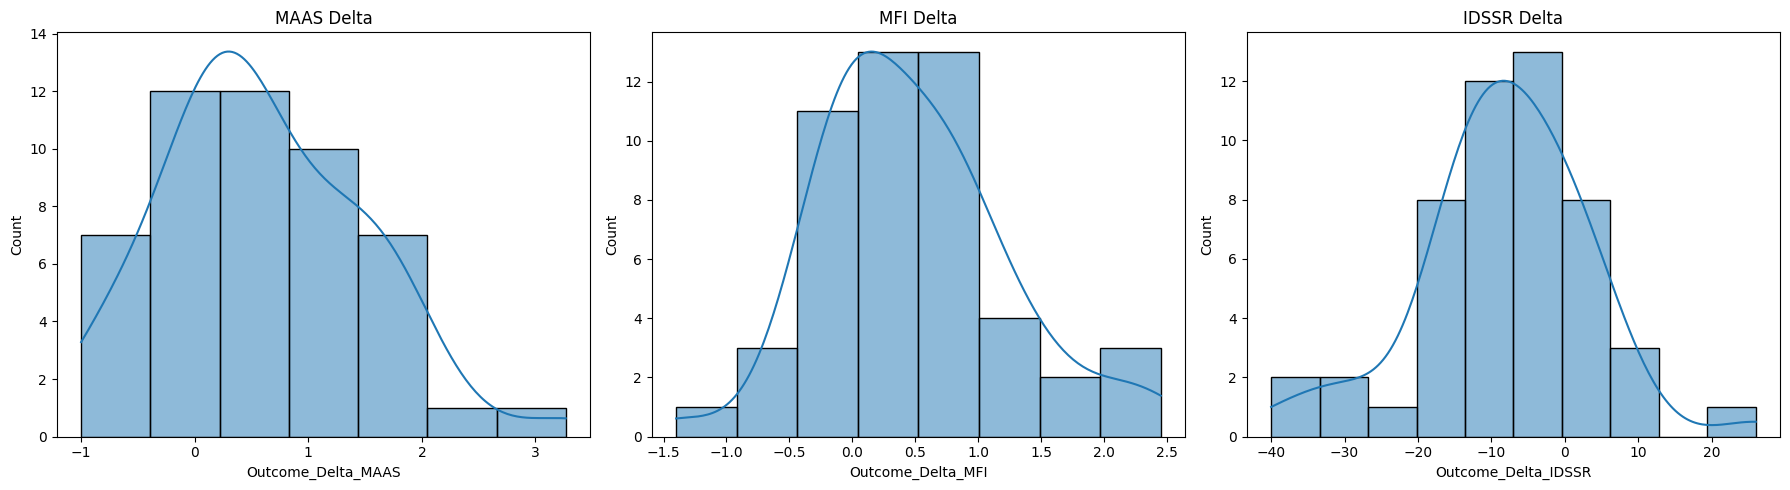

In [8]:
# Rename deltas to match new naming scheme
df['Outcome_Delta_MAAS'] = df['Pre3MoPost_Delta_MAAS']
df['Outcome_Delta_MFI'] = df['Pre3MoPost_Delta_MFI']
df['Outcome_Delta_IDSSR'] = df['Pre3MoPost_Delta_IDSSR']
df['Outcome_Delta_SHS'] = df['Pre3MoPost_Delta_SHS']

# Binary outcomes
maas_threshold = df['Outcome_Delta_MAAS'].std()
df['Responder_MAAS'] = (df['Outcome_Delta_MAAS'] >= maas_threshold).astype(int)
df['Responder_MFI'] = (df['Outcome_Delta_MFI'] < 0).astype(int)

# Define global PWB improvement: 4+ of 6 Ryff subscales improved
ryff_subscales = [
    'RYFF_Autonomy_Score', 'RYFF_EnvironmentalMastery_Score', 'RYFF_PersonalGrowth_Score',
    'RYFF_PositiveRelations_Score', 'RYFF_PurposeInLife_Score', 'RYFF_SelfAcceptance_Score'
]
ryff_deltas = [f'Pre3MoPost_Delta_{sub}' for sub in ryff_subscales]
df['Responder_Global_Ryff'] = (df[ryff_deltas].gt(0).sum(axis=1) >= 4).astype(int)

# Summary
outcome_summary = {
    'MAAS Responder': df['Responder_MAAS'].sum(),
    'MFI Improved': df['Responder_MFI'].sum(),
    'Global Ryff Responder': df['Responder_Global_Ryff'].sum()
}

# Outcome DataFrame
df_outcomes = df[[
    'AnonID', 'Outcome_Delta_MAAS', 'Outcome_Delta_MFI', 'Outcome_Delta_IDSSR',
    'Responder_MAAS', 'Responder_MFI', 'Responder_Global_Ryff'
]]

# Plot deltas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['Outcome_Delta_MAAS'], ax=axes[0], kde=True).set(title='MAAS Delta')
sns.histplot(df['Outcome_Delta_MFI'], ax=axes[1], kde=True).set(title='MFI Delta')
sns.histplot(df['Outcome_Delta_IDSSR'], ax=axes[2], kde=True).set(title='IDSSR Delta')
plt.tight_layout()

outcome_summary


--- All Raw Values Used for Plotting ---
     subject              scale          timepoint  \
0          0  Ryff, Total Score           Baseline   
1          1  Ryff, Total Score           Baseline   
2          2  Ryff, Total Score           Baseline   
3          3  Ryff, Total Score           Baseline   
4          4  Ryff, Total Score           Baseline   
..       ...                ...                ...   
745       45                SHS  3-Month Follow-up   
746       46                SHS  3-Month Follow-up   
747       47                SHS  3-Month Follow-up   
748       48                SHS  3-Month Follow-up   
749       49                SHS  3-Month Follow-up   

                         column     value  
0                PRE_RYFF_Total  4.976190  
1                PRE_RYFF_Total  3.976190  
2                PRE_RYFF_Total  4.380952  
3                PRE_RYFF_Total  4.571429  
4                PRE_RYFF_Total  5.023810  
..                          ...       ...  
7

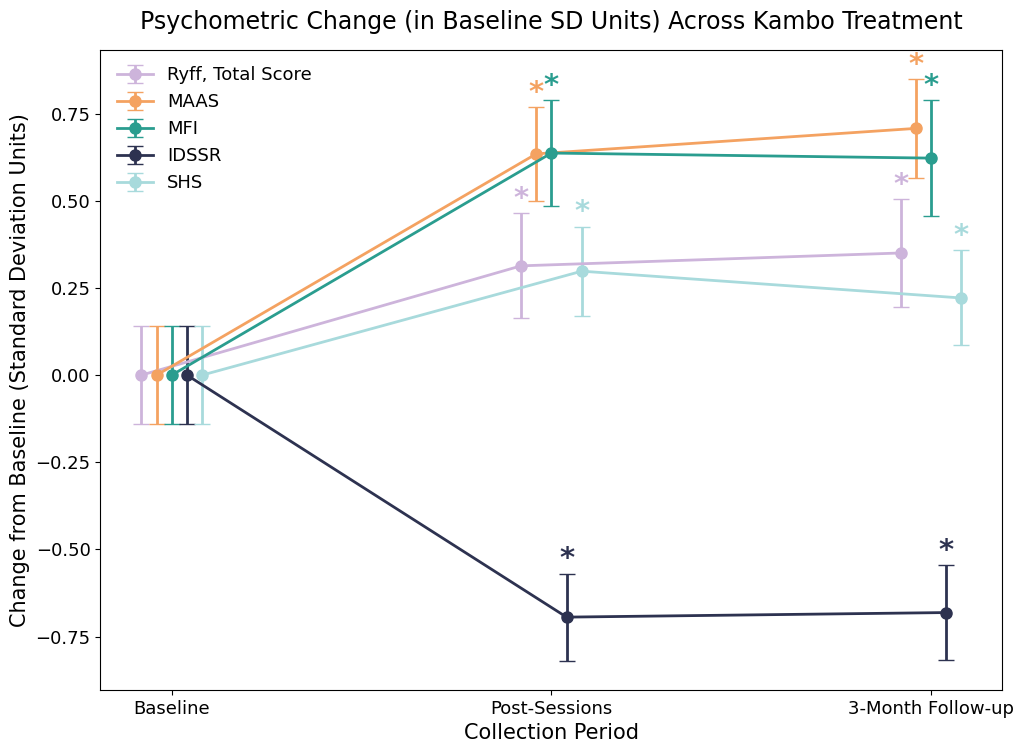

In [9]:
# Define the color palette
color_map = {
    "Ryff, Total Score": '#cdb4db',   # Lavender
    "MAAS": '#f4a261',                # Orange
    "MFI": '#2a9d8f',                 # Aqua
    "SHS": '#a8dadc',               # Robin's egg blue
    "IDSSR": '#2d3250',                 # Navy blue
}

# Timepoint and label mapping
scale_map = {
    "Ryff, Total Score": ['PRE_RYFF_Total', 'RYFF_Total_POST', 'RYFF_Total_3MONTHSPOST'],
    "MAAS": ['PRE_MAAS_Total', 'MAAS_Total_POST', 'MAAS_Total_3MONTHSPOST'],
    "MFI": ['PRE_MFI_TotalScore', 'MFI_TotalScore_POST', 'MFI_TotalScore_3MONTHSPOST'],
    "IDSSR": ['PRE_IDS_TotalScore', 'IDS_TotalScore_POST', 'IDS_TotalScore_3MONTHSPOST'],
    "SHS": ['PRE_SHS_TotalScore', 'SHS_TotalScore_POST', 'SHS_TotalScore_3MONTHSPOST'],
}
timepoints = ['Baseline', 'Post-Sessions', '3-Month Follow-up']

# Containers for group stats
mean_scores = {}
sem_scores = {}
z_all = {}
scale_names = list(scale_map.keys())
offsets = np.linspace(-0.080, 0.080, len(scale_names))  # Evenly spaced offsets

# --- Create a long-form DataFrame of all raw values used in the plot ---

long_records = []

for scale, cols in scale_map.items():
    for i, col in enumerate(cols):
        # Use .items() to retain subject index
        for idx, value in df[col].items():
            long_records.append({
                "subject": idx,
                "scale": scale,
                "timepoint": timepoints[i],
                "column": col,
                "value": value
            })

all_raw_values_df = pd.DataFrame(long_records)
print("\n--- All Raw Values Used for Plotting ---")
print(all_raw_values_df)

# --- Create a long-form DataFrame of all raw values used in the plot ---

all_raw_values_df.to_csv("all_raw_values_for_plotting.csv", index=False)
!cp all_raw_values_for_plotting.csv "/content/drive/My Drive/Kambo/"

for scale, cols in scale_map.items():
    print(f"\n--- {scale} ---")
    data = df[cols].copy()
    for i, col in enumerate(cols):
        col_values = data[col].dropna().values
        print(f"{timepoints[i]} ({col}):")
        print(f"  Values: {col_values}")
        print(f"  Mean: {np.mean(col_values):.3f}, Median: {np.median(col_values):.3f}")
    baseline_mean = data[cols[0]].mean()
    baseline_sd = data[cols[0]].std()
    z_data = (data - baseline_mean) / baseline_sd
    z_all[scale] = z_data
    mean_scores[scale] = z_data.mean().values
    sem_scores[scale] = z_data.sem().values
    print(f"\nZ-scores ({scale}):")
    for i, col in enumerate(cols):
        z_values = z_data[col].dropna().values
        print(f"  {timepoints[i]}: {z_values}")
        print(f"    Z-Mean: {np.mean(z_values):.3f}, Z-Median: {np.median(z_values):.3f}")


print("Keys in mean_scores:", list(mean_scores.keys()))
print("Keys in sem_scores:", list(sem_scores.keys()))
print("Keys in z_all:", list(z_all.keys()))
print("Scale names:", scale_names)

for scale in scale_names:
    if scale not in mean_scores:
        print(f"Missing in mean_scores: {scale}")
    if scale not in sem_scores:
        print(f"Missing in sem_scores: {scale}")
    if scale not in z_all:
        print(f"Missing in z_all: {scale}")

# --- Plotting ---
fig, ax = plt.subplots(figsize=(11, 8))

time_idx = np.arange(len(timepoints))
for i, scale in enumerate(scale_names):
    ax.errorbar(
        time_idx + offsets[i], mean_scores[scale], yerr=sem_scores[scale],
        label=scale, color=color_map[scale],
        marker='o', markersize=8, linewidth=2, capsize=6,
    )

    # Add significance stars
    z = z_all[scale]
    for t, idx in zip(['Post-Sessions', '3-Month Follow-up'], [1, 2]):
        p = ttest_rel(z.iloc[:, 0], z.iloc[:, idx], nan_policy='omit').pvalue
        if p < 0.05:
            y_star = mean_scores[scale][idx] + sem_scores[scale][idx] + 0.001
            ax.text(time_idx[idx] + offsets[i], y_star, '*', ha='center', va='bottom',
                    color=color_map[scale], fontsize=21, fontweight='bold')

ax.set_ylabel('Change from Baseline (Standard Deviation Units)', fontsize=15)
ax.set_xlabel('Collection Period', fontsize=15)
ax.set_title('Psychometric Change (in Baseline SD Units) Across Kambo Treatment', fontsize=17, pad=15)
ax.set_xticks(time_idx)
ax.set_xticklabels(timepoints, fontsize=13)
ax.tick_params(axis='both', labelsize=13)
ax.legend(frameon=False, loc='upper left', fontsize=13)
plt.tight_layout()
plt.subplots_adjust(left=0.16, right=0.98, top=0.91, bottom=0.11)
figpath = "Figure 2_zscore.png"
plt.savefig(figpath, dpi=600, bbox_inches='tight')
!cp psychometric_change_zscore.png "/content/drive/My Drive/Kambo/"

all_means = pd.DataFrame(mean_scores, index=timepoints)
all_sems = pd.DataFrame(sem_scores, index=timepoints)
all_means.to_csv("Figure 2_zscore_means.csv")
all_sems.to_csv("Figure 2_zscore_sems.csv")
!cp Figure 2_zscore_means.csv "/content/drive/My Drive/Kambo/"
!cp Figure 2_change_zscore_sems.csv "/content/drive/My Drive/Kambo/"

plt.show()


In [10]:
for scale, cols in scale_map.items():
    print(f"\n--- {scale} ---")
    data = df[cols]
    baseline_mean = data[cols[0]].mean()
    baseline_sd = data[cols[0]].std()
    z_data = (data - baseline_mean) / baseline_sd
    print("Raw means:", data.mean().values)
    print("Z means:  ", z_data.mean().values)


--- Ryff, Total Score ---
Raw means: [4.72714286 4.86667828 4.88310105]
Z means:   [7.19424520e-16 3.13471824e-01 3.50366211e-01]

--- MAAS ---
Raw means: [3.52933333 4.07142857 4.13385714]
Z means:   [3.55271368e-17 6.34688628e-01 7.07780405e-01]

--- MFI ---
Raw means: [3.15417797 3.642      3.63088828]
Z means:   [-9.61453139e-16  6.37041528e-01  6.22530855e-01]

--- IDSSR ---
Raw means: [24.76 16.28 16.44]
Z means:   [-1.28577704e-16 -6.94322671e-01 -6.81222243e-01]

--- SHS ---
Raw means: [4.55900666 5.005      4.89      ]
Z means:   [2.46469511e-16 2.98171125e-01 2.21287288e-01]


In [11]:
# --- Calculate means and SEMs for raw and z-scores ---

raw_means = {}
raw_sems = {}
z_means = {}
z_sems = {}

for scale, cols in scale_map.items():
    data = df[cols]
    baseline_mean = data[cols[0]].mean()
    baseline_sd = data[cols[0]].std()
    z_data = (data - baseline_mean) / baseline_sd

    # Store means/SEMs
    raw_means[scale] = data.mean().values
    raw_sems[scale] = data.sem().values
    z_means[scale] = z_data.mean().values
    z_sems[scale] = z_data.sem().values

# --- Build the pretty combo table ---

index = scale_names
columns = pd.MultiIndex.from_product([timepoints, ["Raw Mean ± SEM", "Z Mean ± SEM"]])

combo_table = pd.DataFrame(index=index, columns=columns)

for scale in scale_names:
    for i, tp in enumerate(timepoints):
        # Raw
        mean_raw = raw_means[scale][i]
        sem_raw = raw_sems[scale][i]
        combo_table.loc[scale, (tp, "Raw Mean ± SEM")] = f"{mean_raw:.2f} ± {sem_raw:.2f}"
        # Z
        mean_z = z_means[scale][i]
        sem_z = z_sems[scale][i]
        combo_table.loc[scale, (tp, "Z Mean ± SEM")] = f"{mean_z:.2f} ± {sem_z:.2f}"

combo_table.index.name = "Scale"
combo_table.columns.names = ["Timepoint", "Score Type"]

# --- Style function ---

def style_supp_table(df):
    styled = (
        df.style
        .format(na_rep="N/A")
        .set_properties(**{
            'text-align': 'center',
            'font-size': '10pt',
            'min-width': '80px',   # Ensures columns have extra width
            'padding': '8px 16px'  # Extra horizontal space
        })
        .set_table_styles([
            {'selector': 'th', 'props': [('font-size', '11pt'), ('text-align', 'center'), ('min-width', '90px'), ('padding', '10px 16px')]},
            {'selector': 'td', 'props': [('padding', '8px 16px')]},
            {'selector': 'thead th', 'props': [('border-bottom', '2px solid black')]},
        ])
        .hide(axis="index")
        .set_caption("Supplementary Table 3")
    )
    return styled

styled = style_supp_table(combo_table)
dfi.export(styled, "Supplementary_Table_3_Scales.png", table_conversion="matplotlib")
!cp Supplementary_Table_3_Scales.png "/content/drive/MyDrive/Kambo/"
styled

In [12]:
def has_integer_in_label(label):
    """Returns True if any integer is present in the pretty column label."""
    return bool(re.search(r'\d+', label))

# Load data as before...
df_nonimputed_final = pd.read_csv('/content/drive/MyDrive/Kambo/df_nonimputed_final.csv', index_col=False)
df_long_with_deltas = pd.read_csv('/content/drive/MyDrive/Kambo/df_long_with_deltas.csv', index_col=False)
# --- Load label map ---
label_map_df = pd.read_csv('/content/drive/MyDrive/Kambo/label_map_cleaned.csv', index_col=False)
label_map = dict(zip(label_map_df['Original Column'], label_map_df['Cleaned Label']))

# Use only Phase 1
df_demo = df_nonimputed_final[df_nonimputed_final['Phase'] == 1].copy()
print(f"Demo summary will use N={df_demo.shape[0]} participants.")

# Remove unwanted columns
cols_to_remove = ['DEMO_Gender']  # add more as needed

# --- Define true demographic columns ---
true_demo_keys = [
    'DEMO_Age', 'DEMO_Sex', 'DEMO_Education', 'DEMO_Income', 'DEMO_BMI',
    'DEMO_Race', 'DEMO_Ethnicity', 'DEMO_Autoimmu', 'DEMO_Height_in', 'DEMO_Weight_lb',
    'DEMO_Cannabis_Use', 'DEMO_Lyme_DX', 'DEMO_Psychedelic_Use'
]

# filter with pretty label pattern exclusion
def is_true_demographic(col, pretty_label):
    session_keywords = [
        'Session', 'Vomit', 'BM', 'Fainting', 'Private_or_group', 'Rapeh', 'Sananga', 'Points'
    ]
    if re.search(r'\d+', pretty_label):
        return False
    for word in session_keywords:
        if word.lower() in pretty_label.lower():
            return False
    return True

raw_demo_cols = [col for col in df_nonimputed_final.columns if col.startswith('DEMO_')]
pretty_demo_cols = [label_map.get(col, col) for col in raw_demo_cols]
raw_to_pretty = dict(zip(raw_demo_cols, pretty_demo_cols))

demo_cols = [
    col for col in df_demo.columns
    if col in true_demo_keys
    and is_true_demographic(col, raw_to_pretty.get(col, col))
]

# Update pretty mapping
raw_to_pretty.update({'DEMO_Sex': 'Sex, Male'})
raw_to_pretty.update({'DEMO_Days_btwn': 'Days Between Initial and Final Session'})
raw_to_pretty.update({'DEMO_Nervous': 'Nervousness Prior to First Session, 1-10 Scale'})
raw_to_pretty.update({'DEMO_Nervous': 'Nervousness Prior to First Session, 1-10 Scale'})
raw_to_pretty.update({'DEMO_Cannabis_Use': 'Cannabis Use (0 = None, 1 = Some, 2 = Frequent)'})
raw_to_pretty.update({'DEMO_Autoimmu': 'Diagnosed Autoimmune Disease'})
raw_to_pretty.update({'DEMO_Income': 'Income, in Thousands of Dollars'})

main_scales = [
    'Pre3MoPost_Delta_IDSSR',
    'Pre3MoPost_Delta_MFI',
    'Pre3MoPost_Delta_MAAS',
    'Pre3MoPost_Delta_SHS',
    'Pre3MoPost_Delta_Ryff'
]

# Should match column names in non-imputed df
print(df_long_with_deltas.columns[df_long_with_deltas.columns.str.contains('MAAS', case=False)])
print(df_long_with_deltas[['MAAS_Total_3MONTHSPOST', 'PRE_MAAS_Total']].head())

for scale in main_scales:
    if scale not in df_long_with_deltas.columns:
        print(f"{scale} not found in df_long_with_deltas!")
    else:
        col = df_long_with_deltas[scale]
        print(f"{scale}: N={col.notnull().sum()} non-missing, mean={col.mean():.2f}, std={col.std():.2f}")

summary_rows = []

print("Columns in df_demo:", df_demo.columns.tolist())
print("Columns included as demo_cols:", demo_cols)
print("Columns that are missing:", [col for col in true_demo_keys if col not in demo_cols])

for raw_col in demo_cols:
    pretty_col = raw_to_pretty.get(raw_col, raw_col)
    vals = df_demo[raw_col]
    nunique = vals.nunique(dropna=False)
    # Treat as binary if either standard logic OR pretty label has an integer
    is_binary = (
        nunique == 2 and vals.notnull().sum() > 0
    ) or has_integer_in_label(pretty_col)
    row = {"Characteristic": pretty_col}

    if is_binary:
        try:
            val_display = 1 if 1 in vals.unique() else max(vals.dropna().unique())
        except Exception:
            val_display = vals.dropna().unique()[0]
        n = (vals == val_display).sum()
        total = vals.notnull().sum()
        pct = (n / total) * 100 if total > 0 else np.nan
        row["Value"] = f"{n} ({pct:.1f}%)"
    else:
        vals_clean = pd.to_numeric(vals, errors='coerce').dropna()
        if len(vals_clean) > 0:
            row["Value"] = f"{vals_clean.mean():.1f} ± {vals_clean.std():.1f}"
        else:
            row["Value"] = "N/A"
    summary_rows.append(row)

summary_df_nonimputed_final = pd.DataFrame(summary_rows)

def style_demo_table(df_nonimputed_final):
    styled = (
        df_nonimputed_final.style
        .format(na_rep="N/A", precision=3)
        .set_properties(**{
            'text-align': 'center',
            'font-size': '10pt',
            'font-family': 'Arial, sans-serif'
        })
        .set_table_styles([
            {'selector': 'th', 'props': [('font-size', '11pt'), ('font-weight', 'bold'), ('background-color', '#f8f9fa')]},
            {'selector': 'td', 'props': [('padding', '6px 8px')]},
            {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#f3f3f3')]},
            {'selector': 'caption', 'props': [('caption-side', 'top'), ('font-size', '12pt'), ('font-weight', 'bold')]}
        ])
        .hide(axis="index")
        .set_caption("Supplemental Table 2")
    )
    return styled

styled = style_demo_table(summary_df_nonimputed_final)
dfi.export(styled, "Supplementary_Table_2_Demographics.png", table_conversion="matplotlib", max_rows=-1)
!cp Supplementary_Table_2_Demographics.png "/content/drive/My Drive/Kambo/"


Demo summary will use N=50 participants.
Index(['PRE_MAAS_Total', 'MAAS_Total_POST', 'MAAS_Total_3MONTHSPOST',
       'Pre3MoPost_Delta_MAAS'],
      dtype='object')
   MAAS_Total_3MONTHSPOST  PRE_MAAS_Total
0                     NaN             3.6
1                     NaN             NaN
2                4.533333             NaN
3                     NaN             3.4
4                     NaN             NaN
Pre3MoPost_Delta_IDSSR: N=150 non-missing, mean=-8.32, std=11.53
Pre3MoPost_Delta_MFI: N=147 non-missing, mean=0.49, std=0.74
Pre3MoPost_Delta_MAAS: N=150 non-missing, mean=0.60, std=0.88
Pre3MoPost_Delta_SHS: N=147 non-missing, mean=0.34, std=1.12
Pre3MoPost_Delta_Ryff: N=150 non-missing, mean=0.16, std=0.35
Columns in df_demo: ['Unnamed: 0', 'AnonID', 'Phase', 'DEMO_Days btwn', 'DEMO_Autoimmu', 'PRE_MAAS_Total', 'PRE_RYFF_Total', 'PRE_RYFF_Autonomy_Score', 'PRE_RYFF_EnvironmentalMastery_Score', 'PRE_RYFF_PersonalGrowth_Score', 'PRE_RYFF_PositiveRelations_Score', 'PRE_RYFF_P

In [13]:
df_outcomes.to_csv("df_outcomes.csv", index=False)

In [14]:
# Get all column names
tagged_columns = df.columns.tolist()

# Identify leakage columns using updated naming
leakage_cols = [col for col in tagged_columns if (
    col.startswith("MAAS_Total_POST") or
    col.startswith("MFI_TotalScore_POST") or
    (col.startswith("MFI") and "_POST" in col) or
    col.startswith("IDS_TotalScore_POST") or
    col.startswith("RYFF_Total_POST") or
    (col.startswith("RYFF") and "_POST" in col) or
    col.startswith("SHS_TotalScore_POST") or
    (col.startswith("BPI_") and "_POST" in col) or
    col.endswith("_3MONTHSPOST") or
    (any(prefix in col for prefix in ["MEQ30_", "CEQ30_", "5DASC_"]) and "_POST" in col)
)]

# Also include deltas and responder flags
leakage_cols += [col for col in tagged_columns if any(k in col for k in ['PrePost_Delta_', 'Pre3MoPost_Delta_', 'Post3MoPost_Delta_', 'Outcome_Delta_', 'Responder_', 'Change_', 'DELTA_', 'delta_', 'Outcome_'])]

# Deduplicate and sort
leakage_cols = sorted(set(leakage_cols))

leakage_cols


['5DASC_AnxiousEgoDissolution_Score_POST',
 '5DASC_AuditoryAlterations_Score_POST',
 '5DASC_OceanicBoundlessness_Score_POST',
 '5DASC_ReductionOfVigilance_Score_POST',
 '5DASC_TotalScore_POST',
 '5DASC_VisionaryRestructuralization_Score_POST',
 'BPI_PainInterferenceIndex_3MONTHSPOST',
 'BPI_PainInterferenceIndex_POST',
 'BPI_PainReliefPercent_3MONTHSPOST',
 'BPI_PainReliefPercent_POST',
 'BPI_PainSeverityIndex_3MONTHSPOST',
 'BPI_PainSeverityIndex_POST',
 'CEQ30_Death_SUM_POST',
 'CEQ30_Fear_SUM_POST',
 'CEQ30_Grief_SUM_POST',
 'CEQ30_Insanity_SUM_POST',
 'CEQ30_Isolation_SUM_POST',
 'CEQ30_Paranoia_SUM_POST',
 'CEQ30_PhysicalDistress_SUM_POST',
 'CEQ30_Total_SUM_POST',
 'IDS_TotalScore_3MONTHSPOST',
 'IDS_TotalScore_POST',
 'MAAS_Total_3MONTHSPOST',
 'MAAS_Total_POST',
 'MEQ30_Ineffability_POST',
 'MEQ30_MysticalExperience_POST',
 'MEQ30_PositiveMood_POST',
 'MEQ30_TotalScore_POST',
 'MEQ30_TranscendenceOfTimeAndSpace_POST',
 'MFI_General_Fatigue_Score_3MONTHSPOST',
 'MFI_General_Fati

In [15]:
# --- Load label map ---
label_map_df = pd.read_csv('/content/drive/MyDrive/Kambo/label_map_cleaned.csv', index_col=False)
label_map = dict(zip(label_map_df['Original Column'], label_map_df['Cleaned Label']))

scale_color_palette = {
    'IDSSR': {'lasso': '#457b9d', 'perm': '#a8dadc', 'mdi': '#1d3557', 'pdp': '#457b9d'},
    'MFI': {'lasso': '#2a9d8f', 'perm': '#99d9c9', 'mdi': '#1f776c', 'pdp': '#2a9d8f'},
    'MAAS': {'lasso': '#e07a5f', 'perm': '#f4a261', 'mdi': '#cc5c47', 'pdp': '#e07a5f'},
    'SHS': {'lasso': '#4361ee', 'perm': '#b5c0f9', 'mdi': '#2c3791', 'pdp': '#4361ee'}
}

outcome_variables = {
    'IDSSR': 'Outcome_Delta_IDSSR',
    'MFI': 'Outcome_Delta_MFI',
    'MAAS': 'Outcome_Delta_MAAS',
    'SHS': 'Outcome_Delta_SHS'
}

def parallel_permutation_importance(rf, X, y, n_repeats=30):
    def single_permutation(seed):
        result = permutation_importance(rf, X, y, n_repeats=n_repeats, random_state=seed)
        return result.importances_mean, result.importances_std
    seeds = np.random.randint(0, 1e6, size=10)
    results = Parallel(n_jobs=-1)(delayed(single_permutation)(seed) for seed in seeds)
    means = np.mean([r[0] for r in results], axis=0)
    stds = np.mean([r[1] for r in results], axis=0)
    return means, stds

def single_bootstrap_iteration(X, y, scale_label, random_seed):
    np.random.seed(random_seed)
    sample_idx = np.random.choice(len(X), size=len(X), replace=True)
    X_sample = X.iloc[sample_idx]
    y_sample = y.iloc[sample_idx]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_sample)
    lasso = LassoCV(cv=5, random_state=42, max_iter=20000, n_jobs=-1)
    lasso.fit(X_scaled, y_sample)
    lasso_r2 = lasso.score(X_scaled, y_sample)
    rf = RandomForestRegressor(n_estimators=500, random_state=42)
    rf.fit(X_sample, y_sample)
    rf_r2 = rf.score(X_sample, y_sample)
    return [
        {"Scale": scale_label, "R2 Value": lasso_r2, "Model": "Lasso"},
        {"Scale": scale_label, "R2 Value": rf_r2, "Model": "RF"}
    ]

def run_bootstrap_r2_parallel(X, y, scale_label, n_iterations=1000):
    seeds = np.random.randint(0, 1e6, size=n_iterations)
    results = Parallel(n_jobs=-1)(delayed(single_bootstrap_iteration)(X, y, scale_label, seed) for seed in seeds)
    flat_results = [item for sublist in results for item in sublist]
    return flat_results

def plot_feature_importance_panels_v2(X, y, label_map, outcome_label, filename_prefix, scale_colors):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    lasso = LassoCV(cv=5, random_state=42, max_iter=20000, n_jobs=-1, )
    lasso.fit(X_scaled, y)
    lasso_r2 = cross_val_score(lasso, X_scaled, y, cv=5, scoring='r2').mean()
    rf = RandomForestRegressor(n_estimators=500, random_state=42)
    rf.fit(X, y)
    rf_r2 = cross_val_score(rf, X, y, cv=5, scoring='r2').mean()
    lasso_coef = pd.Series(lasso.coef_, index=X.columns)
    lasso_nonzero_raw = lasso_coef[(lasso_coef != 0) & (abs(lasso_coef) > 0.01)].sort_values(key=abs, ascending=False)
    perm_means, perm_stds = parallel_permutation_importance(rf, X, y, n_repeats=30)
    perm_importances = pd.Series(perm_means, index=X.columns).sort_values(ascending=False).head(10)
    perm_std = pd.Series(perm_stds, index=X.columns)[perm_importances.index]
    mdi_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
    top_features = set(lasso_nonzero_raw.head(10).index).union(perm_importances.index, mdi_importances.index)
    lasso_top = lasso_nonzero_raw[lasso_nonzero_raw.index.intersection(top_features)].sort_values(key=abs, ascending=False)
    perm_top = perm_importances
    perm_top_std = perm_std
    mdi_top = mdi_importances

    # ----- Label map patch: Apply to all display axes -----
    def beautify_index(series):
        newidx = [label_map.get(idx, idx) for idx in series.index]
        out = series.copy()
        out.index = newidx
        return out

    lasso_top_disp = beautify_index(lasso_top)
    perm_top_disp = beautify_index(perm_top)
    perm_top_std_disp = perm_top_std.copy()
    perm_top_std_disp.index = perm_top_disp.index  # ensure std index matches label-mapped
    mdi_top_disp = beautify_index(mdi_top)

    fig, axes = plt.subplots(2, 2, figsize=(24, 14))
    fig.suptitle(f'Top Predictors of Change in {outcome_label} Scores (Pre to 3-Month Follow-Up)', fontsize=16, fontweight='bold')

    # Lasso Coefficient panel
    if not lasso_top_disp.empty:
        lasso_top_disp.sort_values().plot(kind='barh', ax=axes[0, 0], color=scale_colors['lasso'])
    else:
        axes[0, 0].text(0.5, 0.5, 'No Nonzero Lasso Coefficients', ha='center', va='center')
        axes[0, 0].set_axis_off()
    axes[0, 0].set_title(f'Lasso Regression (CV R² = {lasso_r2:.2f})', fontsize=14)
    axes[0, 0].axvline(x=0, color='black', linestyle='--', linewidth=1)
    axes[0, 0].set_xlabel('Standardized Coefficient')
    axes[0, 0].grid(True, axis='x', linestyle='--', alpha=0.6)

    # Permutation importance panel
    axes[0, 1].barh(perm_top_disp.index, perm_top_disp.values, xerr=perm_top_std_disp.values, color=scale_colors['perm'], alpha=0.9)
    axes[0, 1].set_title(f'Permutation Importance (RF, CV R² = {rf_r2:.2f})', fontsize=14)
    axes[0, 1].invert_yaxis()
    axes[0, 1].set_xlabel('Mean Decrease in R²')
    axes[0, 1].grid(True, axis='x', linestyle='--', alpha=0.6)
    for i, (value, label) in enumerate(zip(perm_top_disp.values, perm_top_disp.index)):
        axes[0, 1].text(value, i + 0.15, f'{value:.4f}', va='center', ha='left', fontsize=8, color='black')

    # MDI (RF) importance panel
    mdi_top_disp.sort_values().plot(kind='barh', ax=axes[1, 0], color=scale_colors['mdi'])
    axes[1, 0].set_title('Mean Decrease in Impurity (RF)', fontsize=14)
    axes[1, 0].invert_yaxis()
    axes[1, 0].set_xlabel('Feature Importance')
    axes[1, 0].grid(True, axis='x', linestyle='--', alpha=0.6)

    # PDP panel
    top_features_raw = list(lasso_nonzero_raw.head(3).index)
    if top_features_raw:
        pdp_disp = PartialDependenceDisplay.from_estimator(
            rf, X, top_features_raw, ax=axes[1, 1], kind='average', line_kw={'color': scale_colors['pdp']})
        axes[1, 1].set_title('Partial Dependence (Top 3 Features)', y=1.06)
        for ax, feature in zip(pdp_disp.axes_.ravel(), top_features_raw):
            pretty = label_map.get(feature, feature)
            ax.set_title(pretty, fontsize=12)
            ax.set_ylabel(f'Predicted Δ {outcome_label}')
            ax.set_xlabel(pretty)
            ax.tick_params(axis='x', labelsize=8)
            ax.tick_params(axis='y', labelsize=8)
    else:
        axes[1, 1].text(0.5, 0.5, 'No Partial Dependence Available', ha='center', va='center')
        axes[1, 1].set_axis_off()

    def wrap_labels(ax, width=20, pad=49.5):
        labels = ax.get_yticklabels()
        new_labels = []
        for label in labels:
            text = label.get_text()
            wrapped = '\n'.join(textwrap.wrap(text, width, break_long_words=False))
            new_labels.append(wrapped)
        ax.set_yticks(range(len(new_labels)))
        ax.set_yticklabels(new_labels, ha='center')
        ax.tick_params(axis='y', pad=pad)

    wrap_labels(axes[0, 0])
    wrap_labels(axes[0, 1])
    wrap_labels(axes[1, 0])

    panel_labels = ['A', 'B', 'C', 'D']
    positions = [(0, 0), (0, 1), (1, 0), (1, 1)]
    for plabel, (i, j) in zip(panel_labels, positions):
        axes[i, j].text(-0.15, 1.05, plabel, transform=axes[i, j].transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

    plt.tight_layout(pad=2.5)
    plt.subplots_adjust(left=0.3, right=0.9, wspace=0.4, hspace=0.4)
    plt.figtext(0.5, 0.01, f"Feature importance metrics and partial dependence plots shown for {outcome_label} outcome prediction.", wrap=True, horizontalalignment='center', fontsize=10)
    plt.savefig(f'{filename_prefix}_model_predictors_2x2.png', dpi=600, bbox_inches='tight')
    !cp {filename_prefix}_model_predictors_2x2.png "/content/drive/My Drive/Kambo/"
    plt.close(fig)

    final_top_predictors = pd.DataFrame({
        "Lasso Coefficient": lasso_top_disp,
        "Permutation Importance": perm_top_disp,
        "Permutation SD": perm_top_std_disp,
        "MDI Importance": mdi_top_disp
    })
    return final_top_predictors
    plt.close(fig)

final_top_predictors_all_v2 = {}
r2_bootstrap_list = []
for label, column_name in outcome_variables.items():
    y = df[column_name]
    leakage_vars = leakage_cols
    X = df.drop(columns=[col for col in leakage_vars if col in df.columns])
    X_current = X.select_dtypes(include=['float64', 'int64']).drop(columns=['AnonID'], errors='ignore')
    final_top_predictors_all_v2[label] = plot_feature_importance_panels_v2(
        X_current, y, label_map, label, label.lower(), scale_color_palette[label])
    r2_bootstrap_list.extend(run_bootstrap_r2_parallel(X_current, y, label, n_iterations=500))
combined_df = pd.concat(final_top_predictors_all_v2, axis=1)
combined_df.to_csv("combined_df_predictors.csv", index=False)
!cp combined_df_predictors.csv "/content/drive/My Drive/Kambo/"

In [16]:
r2_df = pd.read_csv('/content/drive/MyDrive/Kambo/continuous_model_r2_summary.csv')

def compute_lasso_r2_perm(X, y, seed):
    np.random.seed(seed)
    y_perm = shuffle(y, random_state=seed)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    lasso = LassoCV(cv=5, random_state=42, max_iter=20000, n_jobs=-1)
    lasso.fit(X_scaled, y_perm)
    return lasso.score(X_scaled, y_perm)

def compute_rf_r2_perm(X, y, seed):
    np.random.seed(seed)
    y_perm = shuffle(y, random_state=seed)
    rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
    rf.fit(X, y_perm)
    return rf.score(X, y_perm)

def get_perm_r2_parallel(model_type, X, y, n_repeats=100):
    seeds = np.random.randint(0, 1e6, size=n_repeats)
    if model_type == "Lasso":
        r2s = Parallel(n_jobs=-1)(delayed(compute_lasso_r2_perm)(X, y, seed) for seed in seeds)
    elif model_type == "RF":
        r2s = Parallel(n_jobs=-1)(delayed(compute_rf_r2_perm)(X, y, seed) for seed in seeds)
    return np.mean(r2s)

perm_r2_dict = {}
for label, column_name in outcome_variables.items():
    y = df[column_name]
    leakage_vars = leakage_cols
    X = df.drop(columns=[col for col in leakage_vars if col in df.columns])
    X_current = X.select_dtypes(include=['float64', 'int64']).drop(columns=['AnonID'], errors='ignore')

    print(f"Computing permutation R² for {label} (Lasso and RF)...")
    lasso_perm_r2 = get_perm_r2_parallel("Lasso", X_current, y, n_repeats=100)
    rf_perm_r2 = get_perm_r2_parallel("RF", X_current, y, n_repeats=100)
    perm_r2_dict[(label, 'Lasso')] = lasso_perm_r2
    perm_r2_dict[(label, 'RF')] = rf_perm_r2
    print(f"{label} | Lasso permutation R²: {lasso_perm_r2:.4f}")
    print(f"{label} | RF permutation R²:    {rf_perm_r2:.4f}")

# --- Update dataframe with the new Permutation R2 values ---
for (scale, model), perm_r2 in perm_r2_dict.items():
    mask = (r2_df['Scale'] == scale) & (r2_df['Model'] == model)
    r2_df.loc[mask, 'Permutation R2'] = perm_r2

r2_df.to_csv('/content/drive/MyDrive/Kambo/continuous_model_r2_summary.csv', index=False)


Computing permutation R² for IDSSR (Lasso and RF)...
IDSSR | Lasso permutation R²: 0.0861
IDSSR | RF permutation R²:    0.8438
Computing permutation R² for MFI (Lasso and RF)...
MFI | Lasso permutation R²: 0.1178
MFI | RF permutation R²:    0.8462
Computing permutation R² for MAAS (Lasso and RF)...
MAAS | Lasso permutation R²: 0.0943
MAAS | RF permutation R²:    0.8480
Computing permutation R² for SHS (Lasso and RF)...
SHS | Lasso permutation R²: 0.1214
SHS | RF permutation R²:    0.8403



--- Debug: Predictors for IDSSR (Outcome_Delta_IDSSR) ---
Shape: (50, 74)
Columns: ['DEMO_Days_btwn', 'DEMO_Autoimmu', 'DEMO_Session1_head', 'DEMO_Session1_neck', 'DEMO_Session1_thorax', 'DEMO_Session1_abdomen', 'DEMO_Session1_pelvis', 'DEMO_Session1_upper_extremity', 'DEMO_Session1_lower_extremity', 'DEMO_Session2_head', 'DEMO_Session2_neck', 'DEMO_Session2_thorax', 'DEMO_Session2_abdomen', 'DEMO_Session2_pelvis', 'DEMO_Session2_upper_extremity', 'DEMO_Session2_lower_extremity', 'DEMO_Session3_head', 'DEMO_Session3_neck', 'DEMO_Session3_thorax', 'DEMO_Session3_abdomen', 'DEMO_Session3_pelvis', 'DEMO_Session3_upper_extremity', 'DEMO_Session3_lower_extremity', 'DEMO_Private_or_group_1_NUM', 'DEMO_Private_or_group_2_NUM', 'DEMO_Private_or_group_3_NUM', 'DEMO_Vomit_1_NUM', 'DEMO_Vomit_2_NUM', 'DEMO_Vomit_3_NUM', 'DEMO_BM_1_NUM', 'DEMO_BM_2_NUM', 'DEMO_BM_3_NUM', 'DEMO_Fainting_1_NUM', 'DEMO_Fainting_2_NUM', 'DEMO_Fainting_3_NUM', 'DEMO_Rapeh_1_NUM', 'DEMO_Rapeh_2_NUM', 'DEMO_Rapeh_3_NUM'

/tmp/ipython-input-26-2994880027.py:207: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipython-input-26-2994880027.py:225: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


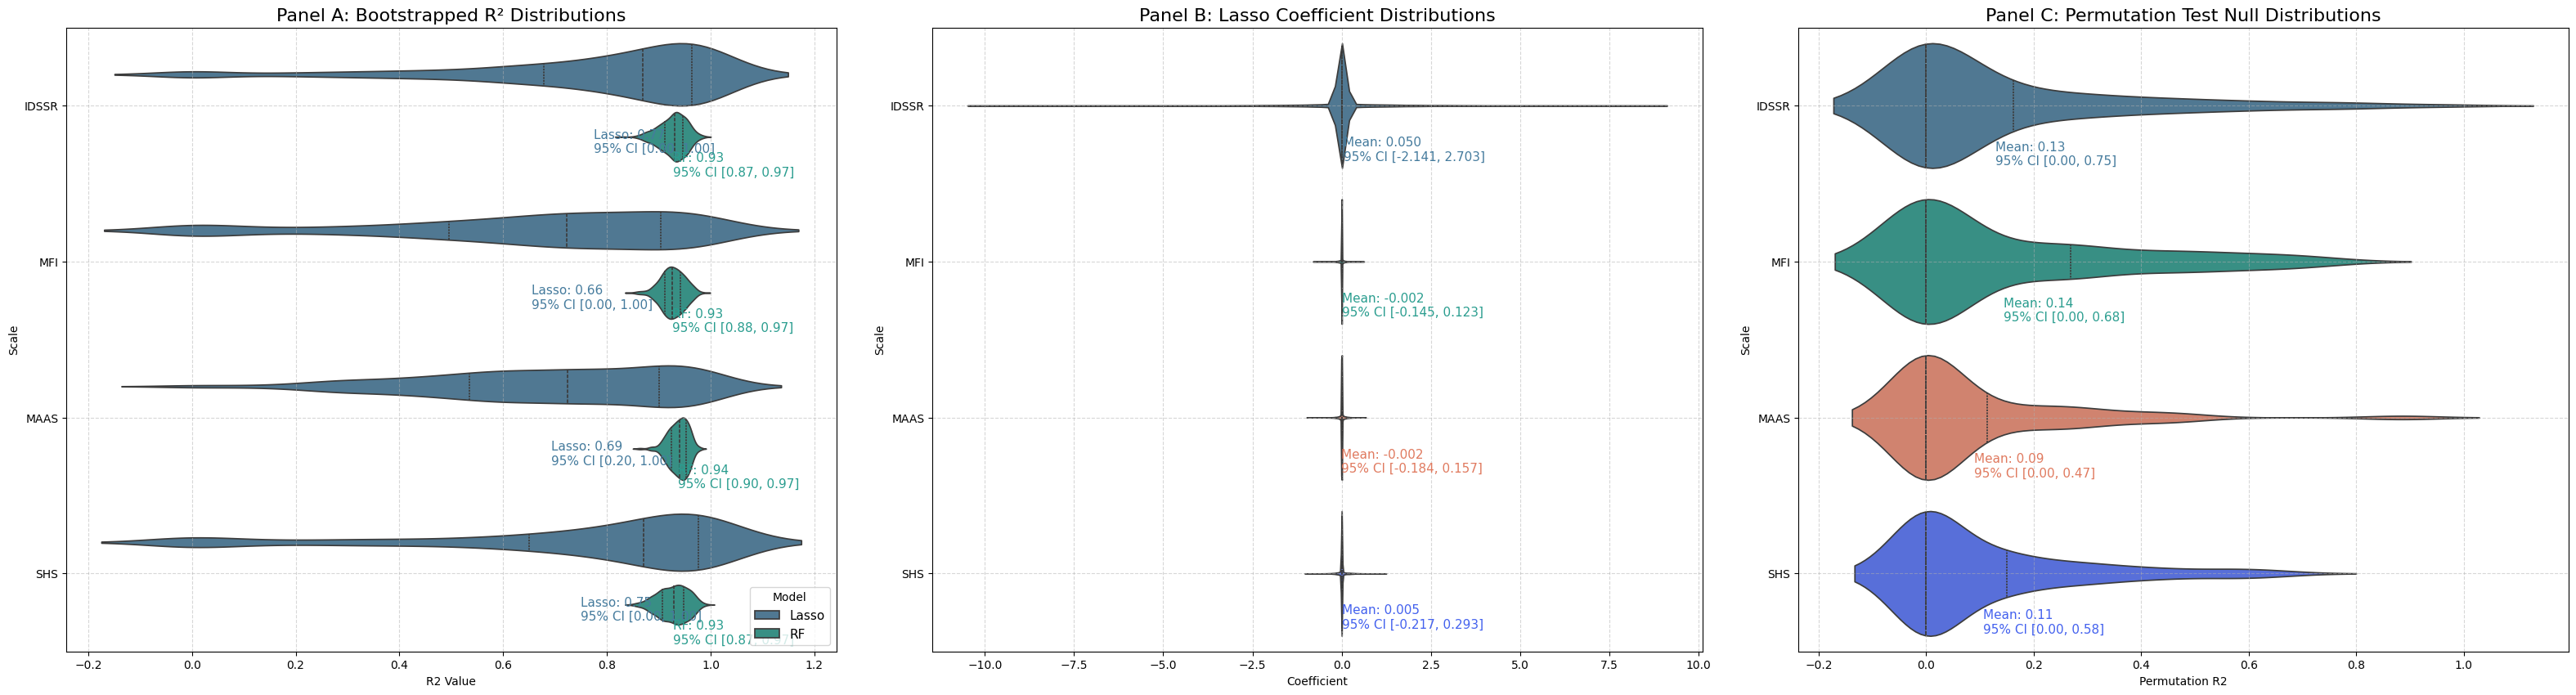

In [26]:
scale_color_palette = {
    'IDSSR': {'lasso': '#457b9d', 'perm': '#a8dadc', 'mdi': '#1d3557', 'pdp': '#457b9d'},
    'MFI': {'lasso': '#2a9d8f', 'perm': '#99d9c9', 'mdi': '#1f776c', 'pdp': '#2a9d8f'},
    'MAAS': {'lasso': '#e07a5f', 'perm': '#f4a261', 'mdi': '#cc5c47', 'pdp': '#e07a5f'},
    'SHS': {'lasso': '#4361ee', 'perm': '#b5c0f9', 'mdi': '#2c3791', 'pdp': '#4361ee'}
}

outcome_variables = {
    'IDSSR': 'Outcome_Delta_IDSSR',
    'MFI': 'Outcome_Delta_MFI',
    'MAAS': 'Outcome_Delta_MAAS',
    'SHS': 'Outcome_Delta_SHS'
}

final_top_predictors_all_v2 = {}
r2_bootstrap_list = []
lasso_coef_list = []
perm_r2_list = []

# --- Kambo Scalar Outcome ML: Debugging and Enhancement ---

from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import textwrap
from joblib import Parallel, delayed

scale_color_palette = {
    'IDSSR': {'lasso': '#457b9d', 'perm': '#a8dadc', 'mdi': '#1d3557', 'pdp': '#457b9d'},
    'MFI': {'lasso': '#2a9d8f', 'perm': '#99d9c9', 'mdi': '#1f776c', 'pdp': '#2a9d8f'},
    'MAAS': {'lasso': '#e07a5f', 'perm': '#f4a261', 'mdi': '#cc5c47', 'pdp': '#e07a5f'},
    'SHS': {'lasso': '#4361ee', 'perm': '#b5c0f9', 'mdi': '#2c3791', 'pdp': '#4361ee'}
}

outcome_variables = {
    'IDSSR': 'Outcome_Delta_IDSSR',
    'MFI': 'Outcome_Delta_MFI',
    'MAAS': 'Outcome_Delta_MAAS',
    'SHS': 'Outcome_Delta_SHS'
}

final_top_predictors_all_v2 = {}
r2_bootstrap_list = []
lasso_coef_list = []
perm_r2_list = []

# Debug step: Print columns for each outcome before fitting
for label, column_name in outcome_variables.items():
    y = df[column_name]
    leakage_vars = leakage_cols
    X = df.drop(columns=[col for col in leakage_vars if col in df.columns])
    X_current = X.select_dtypes(include=['float64', 'int64']).drop(columns=['AnonID'], errors='ignore')
    print(f"\n--- Debug: Predictors for {label} ({column_name}) ---")
    print(f"Shape: {X_current.shape}")
    print("Columns:", list(X_current.columns))
    print(f"Missingness (sum):\n{X_current.isnull().sum()}\n")
    # Optionally: print top few rows
    print("Sample rows:", X_current.head())

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_current)

    # Bootstrap (fix: collect RF bootstrap just like Lasso)
    for _ in range(500):
        sample_idx = np.random.choice(len(X_current), size=len(X_current), replace=True)
        X_sample = X_scaled[sample_idx]
        y_sample = y.iloc[sample_idx]
        lasso = LassoCV(cv=5, random_state=42, max_iter=20000, n_alphas=20, n_jobs=-1)
        lasso.fit(X_sample, y_sample)
        lasso_r2 = lasso.score(X_sample, y_sample)
        r2_bootstrap_list.append({"Scale": label, "R2 Value": lasso_r2, "Model": "Lasso"})
        coef_series = pd.Series(lasso.coef_, index=X_current.columns)
        coef_series['Scale'] = label
        lasso_coef_list.append(coef_series)
        # RF
        rf = RandomForestRegressor(n_estimators=500, random_state=42)
        rf.fit(X_sample, y_sample)
        rf_r2 = rf.score(X_sample, y_sample)
        r2_bootstrap_list.append({"Scale": label, "R2 Value": rf_r2, "Model": "RF"})

    # Parallel permutation R2
    def permuted_lasso_score(X_sample, y_sample):
        permuted_y = np.random.permutation(y_sample)
        lasso_perm = LassoCV(cv=5, random_state=42, max_iter=20000, n_alphas=20, n_jobs=-1)
        lasso_perm.fit(X_sample, permuted_y)
        return lasso_perm.score(X_sample, permuted_y)
    perm_r2_results = Parallel(n_jobs=-1)(delayed(permuted_lasso_score)(X_scaled, y) for _ in range(100))
    for perm_r2 in perm_r2_results:
        perm_r2_list.append({"Scale": label, "Permutation R2": perm_r2})

    # Print Lasso nonzero features
    lasso = LassoCV(cv=5, random_state=42, max_iter=20000, n_alphas=20, n_jobs=-1)
    lasso.fit(X_scaled, y)
    lasso_coef = pd.Series(lasso.coef_, index=X_current.columns)
    lasso_nonzero = lasso_coef[lasso_coef != 0].sort_values(key=abs, ascending=False)
    print(f"Nonzero Lasso features for {label}: {lasso_nonzero}")
    # Print top RF features
    rf = RandomForestRegressor(n_estimators=500, random_state=42)
    rf.fit(X_current, y)
    rf_importance = pd.Series(rf.feature_importances_, index=X_current.columns).sort_values(ascending=False)
    print(f"Top RF features for {label}: {rf_importance.head(10)}")

# Construct Lasso Coef DataFrame
lasso_coef_df = pd.DataFrame(lasso_coef_list)
lasso_coef_df = lasso_coef_df.melt(id_vars=['Scale'], var_name="Feature", value_name="Coefficient")

r2_bootstrap_df = pd.DataFrame(r2_bootstrap_list)
perm_r2_df = pd.DataFrame(perm_r2_list)

# Summarize R² for each outcome/model
summary_r2 = []

# Name of the permuted R2 column
permuted_col = 'Permutation R2' if 'Permutation R2' in r2_bootstrap_df.columns else \
               'Permuted R2' if 'Permuted R2' in r2_bootstrap_df.columns else None

for scale in r2_bootstrap_df['Scale'].unique():
    for model in r2_bootstrap_df['Model'].unique():
        vals = r2_bootstrap_df.loc[
            (r2_bootstrap_df['Scale'] == scale) & (r2_bootstrap_df['Model'] == model), 'R2 Value'
        ].dropna()
        # Permuted R2 values
        perm_vals = r2_bootstrap_df.loc[
            (r2_bootstrap_df['Scale'] == scale) & (r2_bootstrap_df['Model'] == model),
            permuted_col
        ].dropna() if permuted_col else None

        if len(vals) > 0:
            mean = vals.mean()
            ci_lower, ci_upper = np.percentile(vals, [2.5, 97.5])
            # Calculate mean permuted R2 and deltaR2 if possible
            if perm_vals is not None and len(perm_vals) > 0:
                perm_mean = perm_vals.mean()
                delta_r2 = mean - perm_mean
            else:
                perm_mean = np.nan
                delta_r2 = np.nan
            summary_r2.append({
                "Scale": scale,
                "Model": model,
                "N": len(vals),
                "Mean R2": mean,
                "95% CI Lower": ci_lower,
                "95% CI Upper": ci_upper,
                "Permutation R2": perm_mean,
                "Delta R2": delta_r2
            })
r2_summary_df = pd.DataFrame(summary_r2)
print(r2_summary_df)

r2_summary_df.to_csv("continuous_model_r2_summary.csv", index=False)
!cp continuous_model_r2_summary.csv "/content/drive/My Drive/Kambo/"

# Color map for scales
scale_color_map = {k: v['lasso'] for k, v in scale_color_palette.items()}

model_palette = {'Lasso': '#457b9d', 'RF': '#2a9d8f'}

# --- Publication-ready annotated multiplot ---
def plot_validation_figure_with_lasso_and_permutation(r2_bootstrap_df, lasso_coef_df, perm_r2_df, model_palette, scale_color_map):
    fig, axes = plt.subplots(1, 3, figsize=(32, 9))
    # Panel A: R2 violin plot
    sns.violinplot(
        data=r2_bootstrap_df,
        x='R2 Value',
        y='Scale',
        hue='Model',
        palette=model_palette,
        split=False,
        ax=axes[0],
        inner="quartile"
    )
    axes[0].set_title("Panel A: Bootstrapped R² Distributions", fontsize=16)
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].legend(loc='lower right', fontsize=11, title="Model")

    # Annotate Panel A
    for i, scale in enumerate(r2_bootstrap_df['Scale'].unique()):
        for j, model in enumerate(r2_bootstrap_df['Model'].unique()):
            vals = r2_bootstrap_df.loc[(r2_bootstrap_df['Scale'] == scale) & (r2_bootstrap_df['Model'] == model), 'R2 Value']
            if not vals.empty:
                mean = vals.mean()
                ci = np.percentile(vals, [2.5, 97.5])
                axes[0].text(mean, i + 0.3 + 0.15*j, f"{model}: {mean:.2f}\n95% CI [{ci[0]:.2f}, {ci[1]:.2f}]", color=model_palette[model], fontsize=11)

    # Panel B: Lasso Coefficient Distribution
    sns.violinplot(
        data=lasso_coef_df,
        x='Coefficient',
        y='Scale',
        palette=scale_color_map,
        ax=axes[1],
        inner="quartile"
    )
    axes[1].set_title("Panel B: Lasso Coefficient Distributions", fontsize=16)
    axes[1].grid(True, linestyle='--', alpha=0.5)
    # Annotate Panel B
    for i, scale in enumerate(lasso_coef_df['Scale'].unique()):
        vals = lasso_coef_df.loc[lasso_coef_df['Scale'] == scale, 'Coefficient']
        mean = vals.mean()
        ci = np.percentile(vals, [2.5, 97.5])
        axes[1].text(mean, i + 0.35, f"Mean: {mean:.3f}\n95% CI [{ci[0]:.3f}, {ci[1]:.3f}]", color=scale_color_map[scale], fontsize=11)

    # Panel C: Permutation Test Null Distributions
    sns.violinplot(
        data=perm_r2_df,
        x='Permutation R2',
        y='Scale',
        palette=scale_color_map,
        ax=axes[2],
        inner="quartile"
    )
    axes[2].set_title("Panel C: Permutation Test Null Distributions", fontsize=16)
    axes[2].grid(True, linestyle='--', alpha=0.5)
    # Annotate Panel C
    for i, scale in enumerate(perm_r2_df['Scale'].unique()):
        vals = perm_r2_df.loc[perm_r2_df['Scale'] == scale, 'Permutation R2']
        mean = vals.mean()
        ci = np.percentile(vals, [2.5, 97.5])
        axes[2].text(mean, i + 0.38, f"Mean: {mean:.2f}\n95% CI [{ci[0]:.2f}, {ci[1]:.2f}]", color=scale_color_map[scale], fontsize=11)

    plt.tight_layout(pad=2.5)
    plt.savefig("Figure_8_validation.png", dpi=600, bbox_inches="tight")
    !cp Figure_8_validation.png "/content/drive/My Drive/Kambo/"
    plt.close(fig)
    return fig

plot_validation_figure_with_lasso_and_permutation(r2_bootstrap_df, lasso_coef_df, perm_r2_df, model_palette, scale_color_map)


In [18]:
def summarize_top_features(feature_series, label_map, topn=5):
    """Pretty print the top N features with prettified labels and values."""
    if feature_series is None or feature_series.empty:
        return "None"
    top_features = feature_series.reindex(feature_series.abs().sort_values(ascending=False).index).head(topn)
    return "; ".join([f"{label_map.get(idx, idx)} ({val:.2f})" for idx, val in top_features.items()])

summary_rows = []

for scale in outcome_variables:
    # Mean permutation R² for this scale
    perm_df = perm_r2_df.loc[perm_r2_df['Scale'] == scale, 'Permutation R2']
    perm_r2_mean = f"{perm_df.mean():.2f}" if not perm_df.empty else "N/A"
    for model in ['Lasso', 'RF']:
        row = {'Scale': scale, 'Model': model}
        # R² + CI
        model_r2 = r2_summary_df.loc[(r2_summary_df['Scale'] == scale) & (r2_summary_df['Model'] == model)]
        if not model_r2.empty:
            mean_r2 = model_r2['Mean R2'].values[0]
            ci_low = model_r2['95% CI Lower'].values[0]
            ci_high = model_r2['95% CI Upper'].values[0]
            row['R² (95% CI)'] = f"{mean_r2:.2f} ({ci_low:.2f}, {ci_high:.2f})"
        else:
            row['R² (95% CI)'] = "N/A"
        row['Permutation R² (mean)'] = perm_r2_mean
        # Top predictors
        if model == 'Lasso':
            try:
                lasso_feats = final_top_predictors_all_v2[scale]['Lasso Coefficient']
                row['Top 5 Predictors'] = summarize_top_features(lasso_feats, label_map, topn=5)
            except Exception:
                row['Top 5 Predictors'] = "N/A"
        else:
            try:
                rf_feats = final_top_predictors_all_v2[scale]['MDI Importance']
                row['Top 5 Predictors'] = summarize_top_features(rf_feats, label_map, topn=5)
            except Exception:
                row['Top 5 Predictors'] = "N/A"
        summary_rows.append(row)

summary_df = pd.DataFrame(
    summary_rows,
    columns=['Scale', 'Model', 'R² (95% CI)', 'Permutation R² (mean)', 'Top 5 Predictors']
)

def style_ml_results_table(df):
    styled = (
        df.style
        .format(na_rep="N/A")
        .set_properties(**{
            'text-align': 'center',
            'font-size': '11pt'
        })
        .set_table_styles([
            {'selector': 'th', 'props': [('font-size', '12pt'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '7px 10px')]},
            {'selector': 'thead th', 'props': [('border-bottom', '2px solid black')]}
        ])
        .hide(axis="index")
        .set_caption("Supplementary Table 4")
    )
    return styled

styled = style_ml_results_table(summary_df)
dfi.export(styled, "Supplementary_Table_4_ML_Results.png", table_conversion="matplotlib")
styled

Scale,Model,R² (95% CI),Permutation R² (mean),Top 5 Predictors
IDSSR,Lasso,"0.76 (0.00, 1.00)",0.11,N/A
IDSSR,RF,"0.93 (0.87, 0.97)",0.11,N/A
MFI,Lasso,"0.64 (0.00, 1.00)",0.11,N/A
MFI,RF,"0.93 (0.88, 0.97)",0.11,N/A
MAAS,Lasso,"0.69 (0.13, 1.00)",0.13,N/A
MAAS,RF,"0.94 (0.90, 0.97)",0.13,N/A
SHS,Lasso,"0.77 (0.00, 1.00)",0.10,N/A
SHS,RF,"0.93 (0.87, 0.97)",0.10,N/A


In [3]:
# --- Load everything ---
r2_df = pd.read_csv('/content/drive/MyDrive/Kambo/continuous_model_r2_summary.csv')
label_map_df = pd.read_csv('/content/drive/MyDrive/Kambo/label_map_cleaned.csv')
label_map = dict(zip(label_map_df['Original Column'], label_map_df['Cleaned Label']))

scales = ['IDSSR', 'MFI', 'MAAS', 'SHS']
summary_rows = []

def top5_importance(df, col, pretty_col='Pretty Feature'):
    s = df[[pretty_col, col]].dropna()
    s = s[s[col] != 0]
    if s.empty:
        return "None"
    s = s.reindex(s[col].abs().sort_values(ascending=False).index)
    return "; ".join([f"{row[pretty_col]} ({row[col]:.2f})" for _, row in s.head(5).iterrows()])

for scale in scales:
    # Load the scale-specific importance file
    imp = pd.read_csv(f"/content/drive/MyDrive/Kambo/predictor_importance_{scale}.csv")
    # Map pretty names
    imp['Pretty Feature'] = imp['Feature'].map(lambda x: label_map.get(x, x))
    # Compute top 5s
    top5_lasso = top5_importance(imp, 'Lasso Coefficient')
    top5_perm = top5_importance(imp, 'Permutation Importance')
    top5_mdi = top5_importance(imp, 'MDI Importance')

    # Extract R2 and delta R2 from r2_df
    for model in ['Lasso', 'RF']:
        r = r2_df[(r2_df['Scale'] == scale) & (r2_df['Model'] == model)]
        if not r.empty:
            n = r['N'].values[0] if 'N' in r.columns else ""
            mean_r2 = r['Mean R2'].values[0]
            ci_low = r['95% CI Lower'].values[0]
            ci_high = r['95% CI Upper'].values[0]
            perm_r2_mean = r['Permutation R2'].values[0] if 'Permutation R2' in r.columns and not pd.isna(r['Permutation R2'].values[0]) else ""
            delta_r2 = mean_r2 - perm_r2_mean if perm_r2_mean != "" else ""
            r2_str = f"{mean_r2:.2f} ({ci_low:.2f}, {ci_high:.2f})"
            row = {
                'Scale': scale,
                'Model': model,
                'N': n,
                'R² (95% CI)': r2_str,
                'ΔR²': f"{delta_r2:.2f}" if delta_r2 != "" else "",
                'Top 5 Predictors': top5_lasso if model == 'Lasso' else top5_mdi,
                'Top 5 Permutation Importance': "" if model == 'Lasso' else top5_perm,
            }
            summary_rows.append(row)
        else:
            summary_rows.append({
                'Scale': scale,
                'Model': model,
                'N': "",
                'R² (95% CI)': "N/A",
                'ΔR²': "",
                'Top 5 Predictors': "",
                'Top 5 Permutation Importance': ""
            })

summary_df = pd.DataFrame(summary_rows)

# --- Pretty table styling ---
def style_ml_results_table(df):
    styled = (
        df.style
        .format(na_rep="N/A")
        .set_properties(**{
            'text-align': 'center',
            'font-size': '11pt'
        })
        .set_table_styles([
            {'selector': 'th', 'props': [('font-size', '12pt'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '7px 10px')]},
            {'selector': 'thead th', 'props': [('border-bottom', '2px solid black')]}
        ])
        .hide(axis="index")
        .set_caption("Supplementary Table 4")
    )
    return styled

styled = style_ml_results_table(summary_df)
dfi.export(styled, "Supplementary_Table_4_ML_Results.png", table_conversion="matplotlib")
!cp Supplementary_Table_4_ML_Results.png "/content/drive/MyDrive/Kambo/"
styled

Scale,Model,N,R² (95% CI),ΔR²,Top 5 Predictors,Top 5 Permutation Importance
IDSSR,Lasso,500,"0.77 (0.00, 1.00)",,Vomit 1 (1.74); Income (1.38); Sananga 3 (1.37); Weight in Pounds (-1.30); Baseline Ryff Self-acceptance Score (-1.27),
IDSSR,RF,500,"0.93 (0.87, 0.97)",,Baseline Ryff Personal Growth Score (0.07); Weight in Pounds (0.05); Baseline MAAS Total Score (0.05); Baseline Ryff Total (0.04); BMI (0.04),Baseline MFI Mental Fatigue Score (0.00); Sananga 3 (0.00); Autoimmue Diagnosis (0.00); Baseline MFI Reduced Activity Score (0.00); Private or Group 3 (0.00)
MFI,Lasso,500,"0.66 (0.00, 1.00)",,Vomit 1 (1.74); Income (1.38); Sananga 3 (1.37); Weight in Pounds (-1.30); Baseline Ryff Self-acceptance Score (-1.27),
MFI,RF,500,"0.93 (0.88, 0.97)",,Baseline Ryff Personal Growth Score (0.07); Weight in Pounds (0.05); Baseline MAAS Total Score (0.05); Baseline Ryff Total (0.04); BMI (0.04),Baseline MFI Mental Fatigue Score (0.00); Sananga 3 (0.00); Autoimmue Diagnosis (0.00); Baseline MFI Reduced Activity Score (0.00); Private or Group 3 (0.00)
MAAS,Lasso,500,"0.69 (0.20, 1.00)",,Vomit 1 (1.74); Income (1.38); Sananga 3 (1.37); Weight in Pounds (-1.30); Baseline Ryff Self-acceptance Score (-1.27),
MAAS,RF,500,"0.94 (0.90, 0.97)",,Baseline Ryff Personal Growth Score (0.07); Weight in Pounds (0.05); Baseline MAAS Total Score (0.05); Baseline Ryff Total (0.04); BMI (0.04),Baseline MFI Mental Fatigue Score (0.00); Sananga 3 (0.00); Autoimmue Diagnosis (0.00); Baseline MFI Reduced Activity Score (0.00); Private or Group 3 (0.00)
SHS,Lasso,500,"0.75 (0.00, 1.00)",,Vomit 1 (1.74); Income (1.38); Sananga 3 (1.37); Weight in Pounds (-1.30); Baseline Ryff Self-acceptance Score (-1.27),
SHS,RF,500,"0.93 (0.87, 0.97)",,Baseline Ryff Personal Growth Score (0.07); Weight in Pounds (0.05); Baseline MAAS Total Score (0.05); Baseline Ryff Total (0.04); BMI (0.04),Baseline MFI Mental Fatigue Score (0.00); Sananga 3 (0.00); Autoimmue Diagnosis (0.00); Baseline MFI Reduced Activity Score (0.00); Private or Group 3 (0.00)


Bootstrapped metrics summary:
            AUC                                                        \
          count      mean           std       min  25%  50%  75%  max   
Model                                                                   
Logistic  500.0  0.996221  9.211866e-03  0.942959  1.0  1.0  1.0  1.0   
RF        500.0  1.000000  1.648376e-17  1.000000  1.0  1.0  1.0  1.0   

         Accuracy                                             Precision  \
            count     mean      std   min  25%  50%  75%  max     count   
Model                                                                     
Logistic    500.0  0.98576  0.03071  0.84  1.0  1.0  1.0  1.0     500.0   
RF          500.0  1.00000  0.00000  1.00  1.0  1.0  1.0  1.0     500.0   

                                                          Recall          \
              mean      std       min  25%  50%  75%  max  count    mean   
Model                                                                      


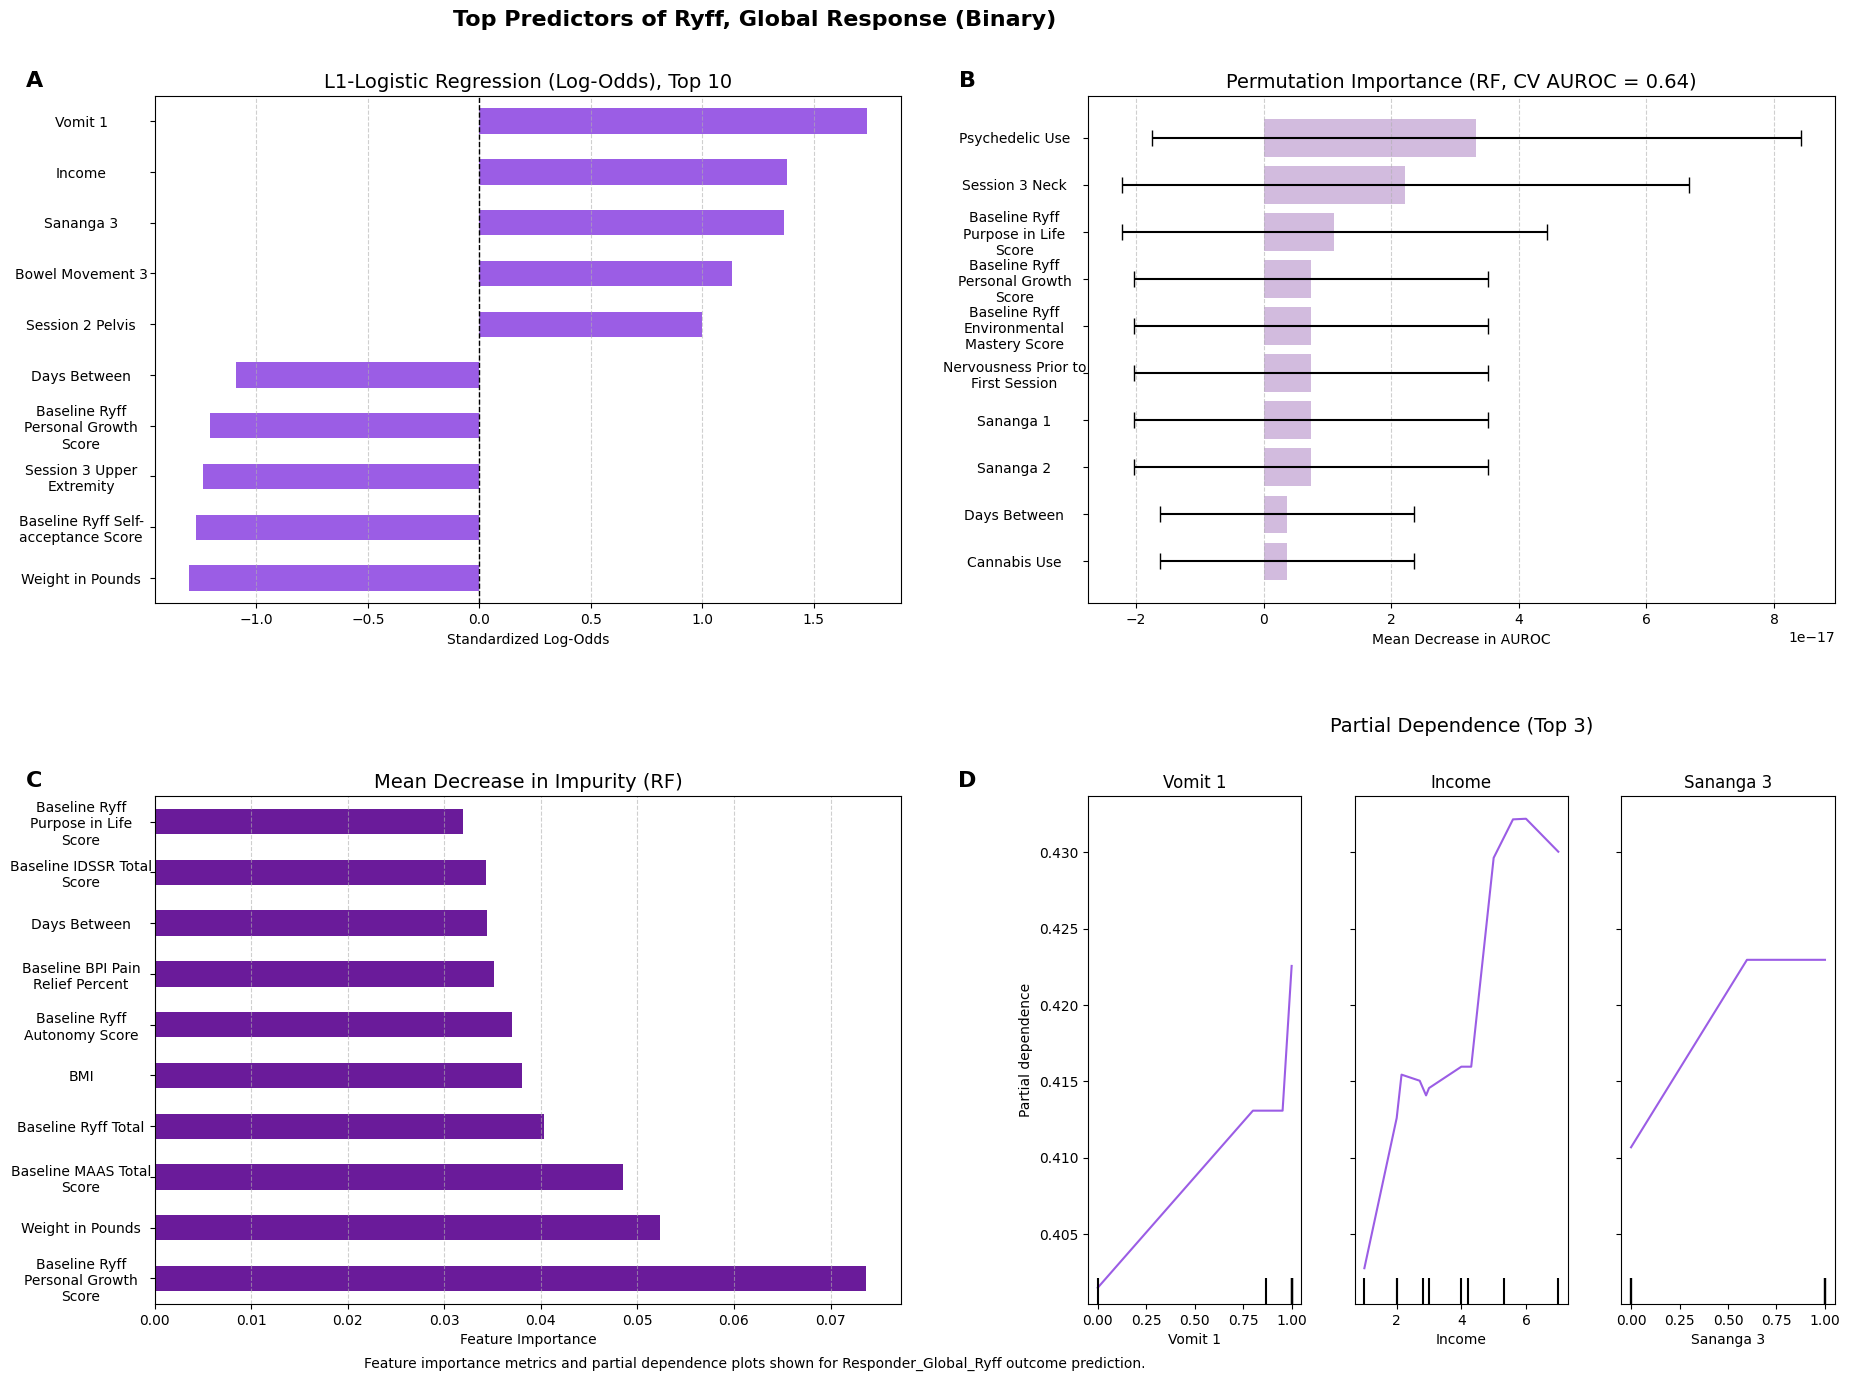

In [20]:
# --- Color Palette ---
palette = {
    'lasso': '#9b5de5',       # Main (Lasso/logistic)
    'perm': '#cdb4db',        # Permutation
    'mdi': '#6a1b9a',         # MDI (Random Forest)
    'pdp': '#9b5de5'          # PDP
}

# --- Load label map ---
label_map_df = pd.read_csv('/content/drive/MyDrive/Kambo/label_map_cleaned.csv', index_col=False)
label_map = dict(zip(label_map_df['Original Column'], label_map_df['Cleaned Label']))

def beautify(labels):
    return [label_map.get(l, l) for l in labels]

# --- Specify outcome and features ---
outcome_label = 'Responder_Global_Ryff'
leakage_vars = leakage_cols

X = df.drop(columns=[col for col in leakage_vars if col in df.columns])
X_current = X.select_dtypes(include=['float64', 'int64']).drop(columns=['AnonID'], errors='ignore')
y = df[outcome_label]

# --- Standardize X ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_current)

# --- Bootstrapping function (unchanged) ---
def single_bootstrap_iteration(X, y, random_seed):
    np.random.seed(random_seed)
    idx = np.random.choice(len(X), size=len(X), replace=True)
    X_sample = X[idx, :]
    y_sample = y.iloc[idx]

    logistic = LogisticRegressionCV(
        Cs=10, cv=5, penalty='l1', solver='saga', max_iter=10000,
        n_jobs=-1, scoring='roc_auc', random_state=42, class_weight='balanced'
    )
    logistic.fit(X_sample, y_sample)
    y_pred_prob = logistic.predict_proba(X_sample)[:, 1]
    y_pred = (y_pred_prob > 0.5).astype(int)

    rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1, class_weight='balanced')
    rf.fit(X_sample, y_sample)
    rf_pred_prob = rf.predict_proba(X_sample)[:, 1]
    rf_pred = (rf_pred_prob > 0.5).astype(int)

    metrics = []
    for model, probs, preds, name in [
        (logistic, y_pred_prob, y_pred, 'Logistic'),
        (rf, rf_pred_prob, rf_pred, 'RF')
    ]:
        metrics.append({
            'Model': name,
            'AUC': roc_auc_score(y_sample, probs),
            'Accuracy': accuracy_score(y_sample, preds),
            'Precision': precision_score(y_sample, preds, zero_division=0),
            'Recall': recall_score(y_sample, preds, zero_division=0)
        })
    lasso_coefs = None
    if hasattr(logistic, 'coef_'):
        lasso_coefs = logistic.coef_[0]
    return metrics, lasso_coefs

n_iterations = 500
seeds = np.random.randint(0, 1e6, size=n_iterations)

results = Parallel(n_jobs=-1)(
    delayed(single_bootstrap_iteration)(X_scaled, y, seed) for seed in seeds
)
metrics_bootstrap = [item[0] for item in results]
coefs_bootstrap = [item[1] for item in results]

# --- Flatten and create DataFrames ---
metrics_flat = [dict(**m, Iteration=i) for i, m_list in enumerate(metrics_bootstrap) for m in m_list]
metrics_df = pd.DataFrame(metrics_flat)

coefs_matrix = np.array([c for c in coefs_bootstrap if c is not None])
coefs_df = pd.DataFrame(coefs_matrix, columns=beautify(X_current.columns))
coefs_df['Iteration'] = np.arange(len(coefs_df))

# --- Fit on full data for importances ---
logistic_full = LogisticRegressionCV(
    Cs=10, cv=5, penalty='l1', solver='saga', max_iter=10000,
    n_jobs=-1, scoring='roc_auc', random_state=42
)
logistic_full.fit(X_scaled, y)

rf_full = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf_full.fit(X_current, y)

# Compute cross-validated AUROC for RF
rf_auc = cross_val_score(rf_full, X_current, y, cv=5, scoring='roc_auc').mean()

# Permutation importance (RF, AUROC)
perm = permutation_importance(
    rf_full, X_current, y, n_repeats=30, random_state=42, scoring='roc_auc', n_jobs=-1
)
perm_importances = pd.Series(perm.importances_mean, index=beautify(X_current.columns)).sort_values(ascending=False)
perm_stds = pd.Series(perm.importances_std, index=beautify(X_current.columns))[perm_importances.index]

# MDI
mdi_importances = pd.Series(rf_full.feature_importances_, index=beautify(X_current.columns)).sort_values(ascending=False)

# Lasso coefficients (log-odds)
lasso_coefs = pd.Series(logistic_full.coef_[0], index=beautify(X_current.columns))
lasso_nonzero = lasso_coefs[lasso_coefs.abs() > 0.01].sort_values(key=abs, ascending=False)
lasso_top10 = lasso_nonzero.head(10)

# --- Partial Dependence (top 3 features from lasso, pretty labels) ---
top_features_raw = [k for k, v in label_map.items() if v in lasso_top10.index][:3]

import textwrap

def wrap_labels(ax, width=20, pad=49.5):
    """Wraps long y-axis labels on the given matplotlib axis."""
    labels = ax.get_yticklabels()
    new_labels = []
    for label in labels:
        text = label.get_text()
        wrapped = '\n'.join(textwrap.wrap(text, width, break_long_words=False))
        new_labels.append(wrapped)
    ax.set_yticks(range(len(new_labels)))
    ax.set_yticklabels(new_labels, ha='center')
    ax.tick_params(axis='y', pad=pad)

fig, axes = plt.subplots(2, 2, figsize=(24, 14))
fig.suptitle(f"Top Predictors of Ryff, Global Response (Binary)", fontsize=16, fontweight='bold')

# --- Panel A: L1-logistic (Top 10, pretty labels) ---
if not lasso_top10.empty:
    lasso_top10.sort_values().plot(kind='barh', ax=axes[0, 0], color=palette['lasso'])
    axes[0, 0].set_title("L1-Logistic Regression (Log-Odds), Top 10", fontsize=14)
else:
    axes[0, 0].text(0.5, 0.5, 'No Nonzero Lasso Coefficients', ha='center', va='center')
    axes[0, 0].set_axis_off()
axes[0, 0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_xlabel('Standardized Log-Odds')
axes[0, 0].grid(True, axis='x', linestyle='--', alpha=0.6)
axes[0, 0].set_ylabel('')

# --- Panel B: Permutation Importance (RF, with CIs, wrap, and annotations) ---
perm_top = perm_importances.head(10)
perm_top_std = perm_stds.loc[perm_top.index]
axes[0, 1].barh(perm_top.index, perm_top.values, xerr=perm_top_std.values,
                color=palette['perm'], alpha=0.9, capsize=6)
axes[0, 1].set_title(f'Permutation Importance (RF, CV AUROC = {rf_auc:.2f})', fontsize=14)
axes[0, 1].invert_yaxis()
axes[0, 1].set_xlabel('Mean Decrease in AUROC')
axes[0, 1].grid(True, axis='x', linestyle='--', alpha=0.6)
axes[0, 1].set_ylabel('')

# --- Panel C: MDI (RF) ---
mdi_top = mdi_importances.head(10)
mdi_top.sort_values().plot(kind='barh', ax=axes[1, 0], color=palette['mdi'])
axes[1, 0].set_title('Mean Decrease in Impurity (RF)', fontsize=14)
axes[1, 0].invert_yaxis()
axes[1, 0].set_xlabel('Feature Importance')
axes[1, 0].grid(True, axis='x', linestyle='--', alpha=0.6)
axes[1, 0].set_ylabel('')

# --- Panel D: Partial Dependence (Y-position tweak and label wrapping) ---
reverse_label_map = {v: k for k, v in label_map.items()}
candidate_raw_features = [reverse_label_map.get(pretty, pretty) for pretty in lasso_top10.index]
top_features_raw = [feat for feat in candidate_raw_features if feat in X_current.columns][:3]

if top_features_raw:
    pdp_disp = PartialDependenceDisplay.from_estimator(
        rf_full, X_current, top_features_raw, ax=axes[1, 1], kind='average',
        line_kw={'color': palette['pdp']}
    )
    axes[1, 1].set_title("Partial Dependence (Top 3)", y=1.11, fontsize=14)
    for ax, feature_raw in zip(pdp_disp.axes_.ravel(), top_features_raw):
        pretty = label_map.get(feature_raw, feature_raw)
        ax.set_xlabel(pretty)
        ax.set_title(pretty, fontsize=12)
else:
    axes[1, 1].text(0.5, 0.5, 'No Partial Dependence Available', ha='center', va='center')
    axes[1, 1].set_axis_off()

# --- Label wrapping for all y-axes ---
wrap_labels(axes[0, 0])
wrap_labels(axes[0, 1])
wrap_labels(axes[1, 0])

# --- Panel labels ---
panel_labels = ['A', 'B', 'C', 'D']
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]
for label, (i, j) in zip(panel_labels, positions):
    axes[i, j].text(-0.15, 1.05, label, transform=axes[i, j].transAxes,
                    fontsize=16, fontweight='bold', va='top', ha='right')

plt.tight_layout(pad=2.5)
plt.subplots_adjust(left=0.25, right=0.95, wspace=0.25, hspace=0.38)
plt.figtext(0.5, 0.01, f"Feature importance metrics and partial dependence plots shown for {outcome_label} outcome prediction.",
            wrap=True, horizontalalignment='center', fontsize=10)

figpath = "Figure_7_model_validation.png"
plt.savefig(figpath, dpi=600, bbox_inches='tight')
!cp Figure_7_model_validation.png "/content/drive/My Drive/Kambo/"

# --- Save raw bootstrap and coefficient values (with pretty labels) ---
metrics_df.to_csv("ryff_bootstrap_metrics_balanced.csv", index=False)
!cp ryff_bootstrap_metrics_balanced.csv "/content/drive/My Drive/Kambo/"
coefs_df.to_csv("ryff_lasso_coefficients_bootstrap_balanced.csv", index=False)
!cp ryff_lasso_coefficients_bootstrap_balanced.csv "/content/drive/My Drive/Kambo/"

# --- Print summary tables (pretty labels) ---
print("Bootstrapped metrics summary:")
print(metrics_df.groupby("Model")[['AUC', 'Accuracy', 'Precision', 'Recall']].describe())
print("\nTop L1-Logistic features (log-odds):")
print(lasso_top10)
print("\nTop RF permutation importances:")
print(perm_importances.head(10))


In [21]:
lasso_df = pd.DataFrame({
    'Feature': lasso_top10.index,
    'Lasso Coefficient': lasso_top10.values
})

perm_df = pd.DataFrame({
    'Feature': perm_importances.head(10).index,
    'Permutation Importance': perm_importances.head(10).values
})

mdi_df = pd.DataFrame({
    'Feature': mdi_importances.head(10).index,
    'MDI Importance': mdi_importances.head(10).values
})

combined = lasso_df.merge(perm_df, on="Feature", how="outer").merge(mdi_df, on="Feature", how="outer")
combined.to_csv("predictor_importance_Responder_Global_Ryff.csv", index=False)
metrics_df.to_csv("Responder_Global_Ryff_bootstrap_metrics.csv", index=False)


In [22]:
metrics_df = pd.read_csv('/content/drive/MyDrive/Kambo/Responder_Global_Ryff_bootstrap_metrics.csv')
importance_df = combined.copy()
label_map_df = pd.read_csv('/content/drive/MyDrive/Kambo/label_map_cleaned.csv')
label_map = dict(zip(label_map_df['Original Column'], label_map_df['Cleaned Label']))

# --- Utility for pretty top 5 display ---
def top5_importance(df, col, pretty_col='Feature'):
    s = df[[pretty_col, col]].dropna()
    s = s[s[col] != 0]
    if s.empty:
        return "None"
    s = s.reindex(s[col].abs().sort_values(ascending=False).index)
    return "; ".join([f"{label_map.get(row[pretty_col], row[pretty_col])} ({row[col]:.2f})" for _, row in s.head(5).iterrows()])

# --- Summarize performance metrics ---
summary = metrics_df.groupby('Model').agg(
    AUC_mean = ('AUC', 'mean'),
    AUC_2_5 = ('AUC', lambda x: x.quantile(0.025)),
    AUC_97_5 = ('AUC', lambda x: x.quantile(0.975)),
    Accuracy_mean = ('Accuracy', 'mean'),
    Accuracy_2_5 = ('Accuracy', lambda x: x.quantile(0.025)),
    Accuracy_97_5 = ('Accuracy', lambda x: x.quantile(0.975)),
    Precision_mean = ('Precision', 'mean'),
    Precision_2_5 = ('Precision', lambda x: x.quantile(0.025)),
    Precision_97_5 = ('Precision', lambda x: x.quantile(0.975)),
    Recall_mean = ('Recall', 'mean'),
    Recall_2_5 = ('Recall', lambda x: x.quantile(0.025)),
    Recall_97_5 = ('Recall', lambda x: x.quantile(0.975))
).reset_index()

# --- Top predictors for each model type ---
lasso_top5 = top5_importance(importance_df, 'Lasso Coefficient', 'Feature')
rf_top5 = top5_importance(importance_df, 'MDI Importance', 'Feature')
perm_top5 = top5_importance(importance_df, 'Permutation Importance', 'Feature')

# --- Build pretty summary table ---
rows = []
for _, row in summary.iterrows():
    model = row['Model']
    rows.append({
        'Model': model,
        'AUC (95% CI)': f"{row['AUC_mean']:.2f} ({row['AUC_2_5']:.2f}, {row['AUC_97_5']:.2f})",
        'Accuracy (95% CI)': f"{row['Accuracy_mean']:.2f} ({row['Accuracy_2_5']:.2f}, {row['Accuracy_97_5']:.2f})",
        'Precision (95% CI)': f"{row['Precision_mean']:.2f} ({row['Precision_2_5']:.2f}, {row['Precision_97_5']:.2f})",
        'Recall (95% CI)': f"{row['Recall_mean']:.2f} ({row['Recall_2_5']:.2f}, {row['Recall_97_5']:.2f})",
        'Top 5 Predictors': lasso_top5 if model == 'Logistic' else rf_top5,
        'Top 5 Permutation Importance': "" if model == 'Logistic' else perm_top5
    })

summary_df = pd.DataFrame(rows)

# --- Style and export ---
def style_ml_results_table(df):
    styled = (
        df.style
        .format(na_rep="N/A")
        .set_properties(**{
            'text-align': 'center',
            'font-size': '11pt'
        })
        .set_table_styles([
            {'selector': 'th', 'props': [('font-size', '12pt'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '7px 10px')]},
            {'selector': 'thead th', 'props': [('border-bottom', '2px solid black')]}
        ])
        .hide(axis="index")
        .set_caption("Supplementary Table 5")
    )
    return styled

styled = style_ml_results_table(summary_df)
dfi.export(styled, "Supplementary_Table_5_Ryff.png", table_conversion="matplotlib")
!cp Supplementary_Table_5_Ryff.png "/content/drive/My Drive/Kambo/"

In [23]:
# Load bootstrap metrics for balanced and non-balanced models
balanced_metrics = pd.read_csv('/content/drive/MyDrive/Kambo/ryff_bootstrap_metrics_balanced.csv')
nonbal_metrics = pd.read_csv('/content/drive/MyDrive/Kambo/Responder_Global_Ryff_bootstrap_metrics.csv')

# Group by model and summarize metrics (mean, 2.5%, 97.5%)
def metric_summary(df):
    summary = df.groupby('Model').agg({
        'AUC': ['mean', lambda x: x.quantile(0.025), lambda x: x.quantile(0.975)],
        'Accuracy': ['mean', lambda x: x.quantile(0.025), lambda x: x.quantile(0.975)],
        'Precision': ['mean', lambda x: x.quantile(0.025), lambda x: x.quantile(0.975)],
        'Recall': ['mean', lambda x: x.quantile(0.025), lambda x: x.quantile(0.975)]
    })
    summary.columns = ['_'.join(filter(None, col)).replace('<lambda_0>', '2.5%').replace('<lambda_1>', '97.5%') for col in summary.columns]
    return summary

balanced_summary = metric_summary(balanced_metrics)
nonbal_summary = metric_summary(nonbal_metrics)

balanced_summary.to_csv("balanced_summary.csv", index=False)
!cp balanced_summary.csv "/content/drive/My Drive/Kambo/"
nonbal_summary.to_csv("nonbal_summary.csv", index=False)
!cp nonbal_summary.csv "/content/drive/My Drive/Kambo/"


In [24]:
lasso_df = pd.DataFrame({
    'Feature': lasso_top10.index,
    'Lasso Coefficient': lasso_top10.values
})

perm_df = pd.DataFrame({
    'Feature': perm_importances.head(10).index,
    'Permutation Importance': perm_importances.head(10).values
})

mdi_df = pd.DataFrame({
    'Feature': mdi_importances.head(10).index,
    'MDI Importance': mdi_importances.head(10).values
})

combined = lasso_df.merge(perm_df, on="Feature", how="outer").merge(mdi_df, on="Feature", how="outer")
combined.to_csv("predictor_importance_Responder_Global_Ryff.csv", index=False)
metrics_df.to_csv("Responder_Global_Ryff_bootstrap_metrics.csv", index=False)


In [25]:
# Load coefficients
bal_lasso = pd.read_csv('/content/drive/MyDrive/Kambo/ryff_lasso_coefficients_bootstrap_balanced.csv')
nonbal_lasso = pd.read_csv('/content/drive/MyDrive/Kambo/Responder_Global_Ryff_lasso_coefficients_bootstrap.csv')

# Summarize the mean and CI for each feature
def coef_summary(df):
    feat_means = df.drop(columns=['Iteration', 'Scale'], errors='ignore').mean()
    feat_ci2p5 = df.drop(columns=['Iteration', 'Scale'], errors='ignore').quantile(0.025)
    feat_ci97p5 = df.drop(columns=['Iteration', 'Scale'], errors='ignore').quantile(0.975)
    return pd.DataFrame({
        "Mean": feat_means,
        "2.5%": feat_ci2p5,
        "97.5%": feat_ci97p5
    }).sort_values("Mean", key=abs, ascending=False)

bal_coef_summary = coef_summary(bal_lasso)
nonbal_coef_summary = coef_summary(nonbal_lasso)
bal_coef_summary.to_csv("bal_coef_summary.csv", index=False)
!cp bal_coef_summary.csv "/content/drive/My Drive/Kambo/"
nonbal_coef_summary.to_csv("nonbal_coef_summary.csv", index=False)
!cp nonbal_coef_summary.csv "/content/drive/My Drive/Kambo/"
bal_coef_summary.head(10), nonbal_coef_summary.head(10)


(                                         Mean      2.5%     97.5%
 Baseline Ryff Personal Growth Score -1.086958 -3.311403  0.000000
 Weight in Pounds                    -0.935058 -2.708230  0.000000
 Income                               0.886736  0.000000  2.888734
 Bowel Movement 3                     0.824245  0.000000  2.694870
 Baseline Ryff Self-acceptance Score -0.753336 -2.619175  0.000000
 Vomit 1                              0.693292  0.000000  2.311421
 Sananga 3                            0.678627  0.000000  2.910003
 Days Between                        -0.602263 -2.328263  0.000000
 Session 3 Pelvis                     0.593833  0.000000  1.896579
 Session 3 Head                      -0.589199 -2.020251  0.000000,
                                          Mean      2.5%     97.5%
 Baseline Ryff Personal Growth Score -1.085419 -3.355806  0.000000
 Income                               0.976496  0.000000  2.868748
 Weight in Pounds                    -0.898608 -2.898471  0.0